# Final Statistical Analysis

This notebook contains the statistical analysis of the final benchmark datasets generated for the empirical comparison of Node.js, Bun and Deno.

The four processed datasets used in this notebook had already undergone benchmark-specific completeness and quality-control audits before analysis. The checks performed here are therefore limited to successful import, variable typing and factor ordering required for statistical analysis.

The analysis proceeds by dependent-variable family:

1. HTTP throughput and latency;
2. cold-start time;
3. file I/O performance; and
4. memory usage.

For each metric family, the analysis follows the methodology defined in Chapter 3:

- descriptive statistics;
- visual inspection;
- assumption checks;
- paired omnibus statistical testing;
- post-hoc paired comparisons where justified;
- effect sizes;
- 95% confidence intervals; and
- multiple-comparison adjustment where required.

Overall performance balance and literature-supported architectural interpretation are addressed only after the individual metric analyses have been completed.

In [7]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(readr)

In [8]:
library(tidyverse)
library(rstatix)
library(effectsize)

current_dir <- normalizePath(
  getwd(),
  winslash = "/"
)

project_root <- if (
  basename(current_dir) == "notebooks"
) {
  dirname(current_dir)
} else {
  current_dir
}

project_root

[1] "D:/FOLO_PROJECTS/MASTERS/javascript-runtime-performance-study"

In [9]:
project_root <- if (
  dir.exists("data")
) {
  "."
} else {
  ".."
}

project_root

[1] ".."

In [10]:
http_final <- read_csv(
  file.path(
    project_root,
    "data",
    "processed",
    "http",
    "http_final_combined.csv"
  ),
  show_col_types = FALSE
)

cold_start_final <- read_csv(
  file.path(
    project_root,
    "data",
    "processed",
    "cold_start",
    "cold_start_final.csv"
  ),
  show_col_types = FALSE
)

file_io_final <- read_csv(
  file.path(
    project_root,
    "data",
    "processed",
    "file_io",
    "file_io_final.csv"
  ),
  show_col_types = FALSE
)

memory_final <- read_csv(
  file.path(
    project_root,
    "data",
    "processed",
    "memory",
    "memory_final.csv"
  ),
  show_col_types = FALSE
)

In [11]:
data.frame(
  dataset = c(
    "HTTP",
    "Cold start",
    "File I/O",
    "Memory"
  ),

  observations = c(
    nrow(http_final),
    nrow(cold_start_final),
    nrow(file_io_final),
    nrow(memory_final)
  )
)

dataset,observations
<chr>,<int>
HTTP,180
Cold start,90
File I/O,60
Memory,120


In [12]:
# Standard display order used throughout the analysis
runtime_levels <- c(
  "Node.js",
  "Bun",
  "Deno"
)

# HTTP dataset contains: Node.js, bun, deno
http_final <- http_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c(
        "Node.js",
        "bun",
        "deno"
      ),
      labels = runtime_levels
    ),

    workload = factor(
      workload,
      levels = c(
        "simple",
        "complex"
      ),
      labels = c(
        "Simple",
        "Complex"
      )
    ),

    connections = factor(
      connections,
      levels = c(
        10,
        50,
        100
      )
    )
  )

# Other datasets contain: node, bun, deno
cold_start_final <- cold_start_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c(
        "node",
        "bun",
        "deno"
      ),
      labels = runtime_levels
    )
  )

file_io_final <- file_io_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c(
        "node",
        "bun",
        "deno"
      ),
      labels = runtime_levels
    ),

    operation = factor(
      operation,
      levels = c(
        "read",
        "write"
      ),
      labels = c(
        "Read",
        "Write"
      )
    )
  )

memory_final <- memory_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c(
        "node",
        "bun",
        "deno"
      ),
      labels = runtime_levels
    ),

    workload = factor(
      workload,
      levels = c(
        "idle",
        "allocated"
      ),
      labels = c(
        "Idle",
        "Allocated"
      )
    )
  )

In [13]:
levels(http_final$runtime)
levels(cold_start_final$runtime)
levels(file_io_final$runtime)
levels(memory_final$runtime)

[1] "Node.js" "Bun"     "Deno"

[1] "Node.js" "Bun"     "Deno"

[1] "Node.js" "Bun"     "Deno"

[1] "Node.js" "Bun"     "Deno"

## 1. HTTP Performance Analysis

The HTTP experiment evaluates runtime performance under two workload types:

- **Simple workload:** a minimal fixed JSON response intended to establish baseline native HTTP-serving performance.
- **Complex workload:** a controlled dynamic request-processing task involving JSON parsing, validation, item iteration, arithmetic processing and dynamic response serialisation.

Each workload was tested at three concurrent-connection levels:

- 10 connections;
- 50 connections; and
- 100 connections.

Ten repeated observations were collected for each runtime, workload and connection-level combination.

The primary HTTP throughput metric is requests completed per second. Higher values indicate greater throughput.

The principal latency measures considered for inferential analysis are:

- mean latency, representing typical request latency; and
- p99 latency, representing tail-latency behaviour.

Other recorded latency measures remain available as supporting descriptive information.

In [14]:
http_throughput_summary <- http_final |>
  group_by(
    workload,
    connections,
    runtime
  ) |>
  summarise(
    n = n(),

    mean_rps = mean(
      requests_per_second
    ),

    median_rps = median(
      requests_per_second
    ),

    sd_rps = sd(
      requests_per_second
    ),

    iqr_rps = IQR(
      requests_per_second
    ),

    min_rps = min(
      requests_per_second
    ),

    max_rps = max(
      requests_per_second
    ),

    .groups = "drop"
  )

http_throughput_summary

workload,connections,runtime,n,mean_rps,median_rps,sd_rps,iqr_rps,min_rps,max_rps
<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,10,Node.js,10,16859.00,16823.00,388.0141,444.7000,16192.27,17446.00
Simple,10,NA,20,19044.79,18578.94,1555.7340,1299.3150,16671.87,22207.34
Simple,50,Node.js,10,16025.44,15955.74,538.9635,477.7625,15065.34,16972.27
Simple,50,NA,20,19137.74,18868.40,864.8507,1026.0775,17838.67,21345.47
Simple,100,Node.js,10,15099.96,15398.67,1259.9088,581.8350,11643.34,16009.87
Simple,100,NA,20,18326.07,17926.74,1258.3791,766.7300,15794.80,20878.54
Complex,10,Node.js,10,12471.48,12340.14,259.9425,353.5350,12197.74,12902.47
Complex,10,NA,20,16611.15,16569.21,1647.3981,3063.9675,14371.00,18970.80
Complex,50,Node.js,10,11696.36,11769.07,227.1217,278.4000,11284.20,12008.07


In [15]:
# 95% confidence intervals (t-based)

http_throughput_summary <- http_final |>
  group_by(
    workload,
    connections,
    runtime
  ) |>
  summarise(
    n = n(),

    mean_rps = mean(
      requests_per_second
    ),

    median_rps = median(
      requests_per_second
    ),

    sd_rps = sd(
      requests_per_second
    ),

    se_rps = sd_rps / sqrt(n),

    ci_margin = qt(
      0.975,
      df = n - 1
    ) * se_rps,

    ci_lower = mean_rps - ci_margin,

    ci_upper = mean_rps + ci_margin,

    iqr_rps = IQR(
      requests_per_second
    ),

    min_rps = min(
      requests_per_second
    ),

    max_rps = max(
      requests_per_second
    ),

    .groups = "drop"
  )

http_throughput_summary

workload,connections,runtime,n,mean_rps,median_rps,sd_rps,se_rps,ci_margin,ci_lower,ci_upper,iqr_rps,min_rps,max_rps
<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,10,Node.js,10,16859.00,16823.00,388.0141,122.70085,277.5686,16581.43,17136.57,444.7000,16192.27,17446.00
Simple,10,NA,20,19044.79,18578.94,1555.7340,347.87269,728.1059,18316.69,19772.90,1299.3150,16671.87,22207.34
Simple,50,Node.js,10,16025.44,15955.74,538.9635,170.43524,385.5513,15639.89,16410.99,477.7625,15065.34,16972.27
Simple,50,NA,20,19137.74,18868.40,864.8507,193.38649,404.7626,18732.98,19542.50,1026.0775,17838.67,21345.47
Simple,100,Node.js,10,15099.96,15398.67,1259.9088,398.41816,901.2845,14198.68,16001.25,581.8350,11643.34,16009.87
Simple,100,NA,20,18326.07,17926.74,1258.3791,281.38213,588.9396,17737.13,18915.01,766.7300,15794.80,20878.54
Complex,10,Node.js,10,12471.48,12340.14,259.9425,82.20103,185.9516,12285.52,12657.43,353.5350,12197.74,12902.47
Complex,10,NA,20,16611.15,16569.21,1647.3981,368.36941,771.0060,15840.15,17382.16,3063.9675,14371.00,18970.80
Complex,50,Node.js,10,11696.36,11769.07,227.1217,71.82218,162.4731,11533.89,11858.84,278.4000,11284.20,12008.07


Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`)."


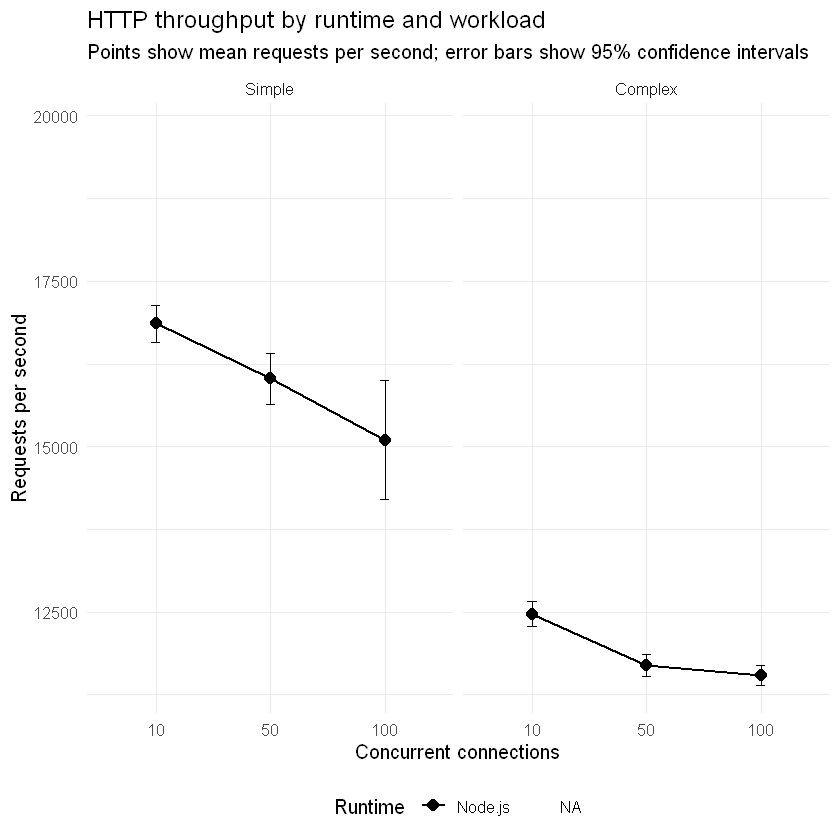

In [16]:
# throughput changes figure

http_throughput_plot <- ggplot(
  http_throughput_summary,
  aes(
    x = connections,
    y = mean_rps,
    group = runtime,
    shape = runtime,
    linetype = runtime
  )
) +
  geom_line(
    linewidth = 0.8
  ) +
  geom_point(
    size = 3
  ) +
  geom_errorbar(
    aes(
      ymin = ci_lower,
      ymax = ci_upper
    ),
    width = 0.08
  ) +
  facet_wrap(
    ~ workload
  ) +
  labs(
    title = "HTTP throughput by runtime and workload",
    subtitle = "Points show mean requests per second; error bars show 95% confidence intervals",
    x = "Concurrent connections",
    y = "Requests per second",
    shape = "Runtime",
    linetype = "Runtime"
  ) +
  theme_minimal(
    base_size = 12
  ) +
  theme(
    legend.position = "bottom"
  )

http_throughput_plot

In [17]:
http_final <- http_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c(
        "Node.js",
        "Bun",
        "Deno"
      )
    ),

    workload = factor(
      workload,
      levels = c(
        "simple",
        "complex"
      ),
      labels = c(
        "Simple",
        "Complex"
      )
    ),

    connections = factor(
      connections,
      levels = c(
        10,
        50,
        100
      )
    )
  )

In [18]:
table(
  http_final$runtime,
  useNA = "ifany"
)


Node.js     Bun    Deno    <NA> 
     60       0       0     120 

In [19]:
#Reloading HTTP from disk again
http_final <- read_csv(
  file.path(
    project_root,
    "data",
    "processed",
    "http",
    "http_final_combined.csv"
  ),
  show_col_types = FALSE
)

In [20]:
table(http_final$runtime, useNA = "ifany")


    Bun    Deno Node.js 
     60      60      60 

In [21]:
# applying name conversion

http_final <- http_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c(
        "Node.js",
        "Bun",
        "Deno"
      )
    ),

    workload = factor(
      workload,
      levels = c(
        "simple",
        "complex"
      ),
      labels = c(
        "Simple",
        "Complex"
      )
    ),

    connections = factor(
      connections,
      levels = c(
        10,
        50,
        100
      )
    )
  )

In [22]:
table(http_final$runtime, useNA = "ifany")


Node.js     Bun    Deno 
     60      60      60 

In [23]:
# HTTP throughput summary
http_throughput_summary <- http_final |>
  group_by(
    workload,
    connections,
    runtime
  ) |>
  summarise(
    n = n(),

    mean_rps = mean(
      requests_per_second
    ),

    median_rps = median(
      requests_per_second
    ),

    sd_rps = sd(
      requests_per_second
    ),

    se_rps = sd_rps / sqrt(n),

    ci_margin = qt(
      0.975,
      df = n - 1
    ) * se_rps,

    ci_lower = mean_rps - ci_margin,

    ci_upper = mean_rps + ci_margin,

    iqr_rps = IQR(
      requests_per_second
    ),

    min_rps = min(
      requests_per_second
    ),

    max_rps = max(
      requests_per_second
    ),

    .groups = "drop"
  )

http_throughput_summary

workload,connections,runtime,n,mean_rps,median_rps,sd_rps,se_rps,ci_margin,ci_lower,ci_upper,iqr_rps,min_rps,max_rps
<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,10,Node.js,10,16859.00,16823.00,388.0141,122.70085,277.5686,16581.43,17136.57,444.7000,16192.27,17446.00
Simple,10,Bun,10,18049.56,18139.27,605.3813,191.43839,433.0637,17616.50,18482.63,584.6000,16671.87,18841.47
Simple,10,Deno,10,20040.02,19302.81,1594.3582,504.18033,1140.5351,18899.49,21180.56,2635.2300,17969.67,22207.34
Simple,50,Node.js,10,16025.44,15955.74,538.9635,170.43524,385.5513,15639.89,16410.99,477.7625,15065.34,16972.27
Simple,50,Bun,10,19256.60,19350.14,559.8659,177.04513,400.5039,18856.10,19657.10,909.7950,18428.14,20018.27
Simple,50,Deno,10,19018.88,18708.40,1110.9444,351.31146,794.7217,18224.16,19813.61,513.4000,17838.67,21345.47
Simple,100,Node.js,10,15099.96,15398.67,1259.9088,398.41816,901.2845,14198.68,16001.25,581.8350,11643.34,16009.87
Simple,100,Bun,10,17642.22,17766.67,755.7689,238.99510,540.6445,17101.57,18182.86,347.7675,15794.80,18437.20
Simple,100,Deno,10,19009.92,18394.53,1316.2685,416.24065,941.6018,18068.32,19951.52,2396.0700,17740.67,20878.54


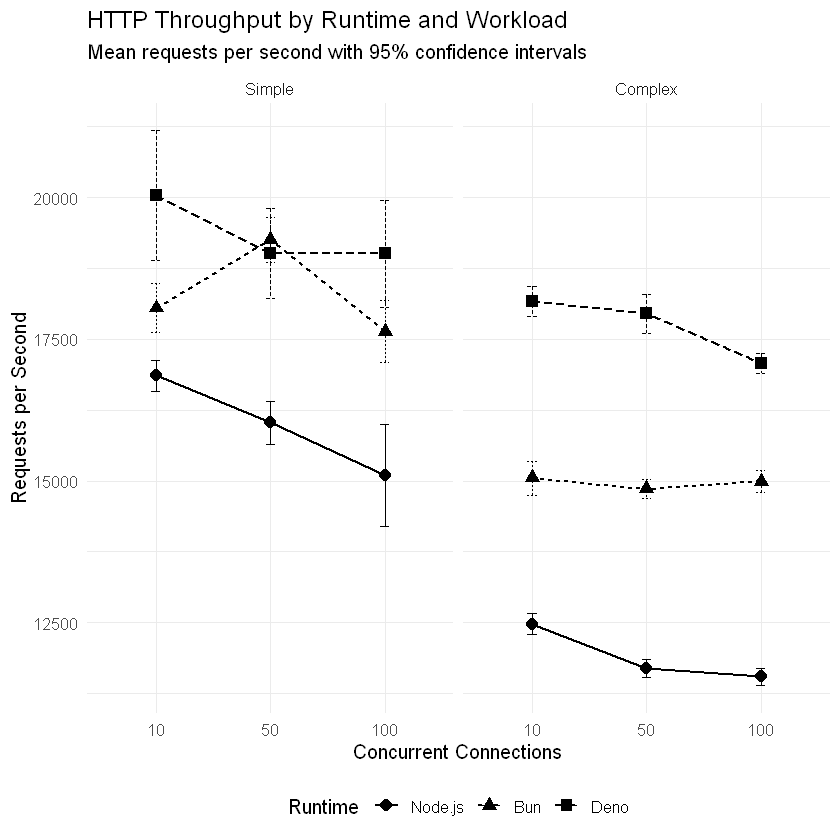

In [24]:
# http throughput graph 
http_throughput_plot <- ggplot(
  http_throughput_summary,
  aes(
    x = connections,
    y = mean_rps,
    group = runtime,
    shape = runtime,
    linetype = runtime
  )
) +
  geom_line(
    linewidth = 0.8
  ) +
  geom_point(
    size = 3
  ) +
  geom_errorbar(
    aes(
      ymin = ci_lower,
      ymax = ci_upper
    ),
    width = 0.08
  ) +
  facet_wrap(
    ~ workload
  ) +
  labs(
    title = "HTTP Throughput by Runtime and Workload",
    subtitle = "Mean requests per second with 95% confidence intervals",
    x = "Concurrent Connections",
    y = "Requests per Second",
    shape = "Runtime",
    linetype = "Runtime"
  ) +
  theme_minimal(
    base_size = 12
  ) +
  theme(
    legend.position = "bottom"
  )

http_throughput_plot

In [25]:
# save graph
http_figure_directory <- file.path(
  project_root,
  "results",
  "figures",
  "http"
)

dir.create(
  http_figure_directory,
  recursive = TRUE,
  showWarnings = FALSE
)

ggsave(
  filename = file.path(
    http_figure_directory,
    "http_throughput_final.png"
  ),
  plot = http_throughput_plot,
  width = 10,
  height = 6,
  dpi = 300
)

 check the normality of the paired throughput differences for each of the six HTTP conditions.

In [26]:
# reload dataset

library(dplyr)
library(tidyr)
library(readr)

project_root <- if (dir.exists("data")) "." else ".."

http_final <- read_csv(
  file.path(
    project_root,
    "data",
    "processed",
    "http",
    "http_final_combined.csv"
  ),
  show_col_types = FALSE
)

http_final <- http_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c(
        "Node.js",
        "Bun",
        "Deno"
      )
    ),

    workload = factor(
      workload,
      levels = c(
        "simple",
        "complex"
      ),
      labels = c(
        "Simple",
        "Complex"
      )
    ),

    connections = factor(
      connections,
      levels = c(
        10,
        50,
        100
      )
    )
  )

In [27]:
table(http_final$runtime)


Node.js     Bun    Deno 
     60      60      60 

In [28]:
http_throughput_wide <- http_final |>
  select(
    workload,
    connections,
    repetition,
    runtime,
    requests_per_second
  ) |>
  pivot_wider(
    names_from = runtime,
    values_from = requests_per_second
  )

http_throughput_wide

workload,connections,repetition,Node.js,Bun,Deno
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,10,1,16192.27,17684.14,18875.34
Simple,10,2,16488.14,16671.87,18576.94
Simple,10,3,16764.00,17784.67,19204.94
Simple,10,4,16743.60,17901.47,21804.67
Simple,10,5,17446.00,18265.20,20957.87
Simple,10,6,17129.34,18420.67,22197.87
Simple,10,7,16966.00,18841.47,19300.67
Simple,10,8,16610.54,18580.94,22207.34
Simple,10,9,17368.14,18331.87,19304.94


In [29]:
# get differences in each observation throughput across runtimes

http_throughput_differences <- http_throughput_wide |>
  mutate(
    `Node.js - Bun` = `Node.js` - Bun,
    `Node.js - Deno` = `Node.js` - Deno,
    `Bun - Deno` = Bun - Deno
  ) |>
  select(
    workload,
    connections,
    repetition,
    `Node.js - Bun`,
    `Node.js - Deno`,
    `Bun - Deno`
  ) |>
  pivot_longer(
    cols = c(
      `Node.js - Bun`,
      `Node.js - Deno`,
      `Bun - Deno`
    ),
    names_to = "comparison",
    values_to = "difference"
  )

http_throughput_differences

workload,connections,repetition,comparison,difference
<fct>,<fct>,<dbl>,<chr>,<dbl>
Simple,10,1,Node.js - Bun,-1491.87
Simple,10,1,Node.js - Deno,-2683.07
Simple,10,1,Bun - Deno,-1191.20
Simple,10,2,Node.js - Bun,-183.73
Simple,10,2,Node.js - Deno,-2088.80
Simple,10,2,Bun - Deno,-1905.07
Simple,10,3,Node.js - Bun,-1020.67
Simple,10,3,Node.js - Deno,-2440.94
Simple,10,3,Bun - Deno,-1420.27


In [30]:
# normality check 
http_throughput_shapiro <- http_throughput_differences |>
  group_by(
    workload,
    connections,
    comparison
  ) |>
  summarise(
    W = unname(
      shapiro.test(difference)$statistic
    ),

    p_value = shapiro.test(difference)$p.value,

    .groups = "drop"
  )

http_throughput_shapiro

workload,connections,comparison,W,p_value
<fct>,<fct>,<chr>,<dbl>,<dbl>
Simple,10,Bun - Deno,0.9208422,0.364032985
Simple,10,Node.js - Bun,0.9568372,0.749295424
Simple,10,Node.js - Deno,0.8965548,0.200734993
Simple,50,Bun - Deno,0.7636126,0.005227872
Simple,50,Node.js - Bun,0.8870280,0.156959027
Simple,50,Node.js - Deno,0.8285997,0.032185900
Simple,100,Bun - Deno,0.8784512,0.125250787
Simple,100,Node.js - Bun,0.7244818,0.001745959
Simple,100,Node.js - Deno,0.9185444,0.344974863


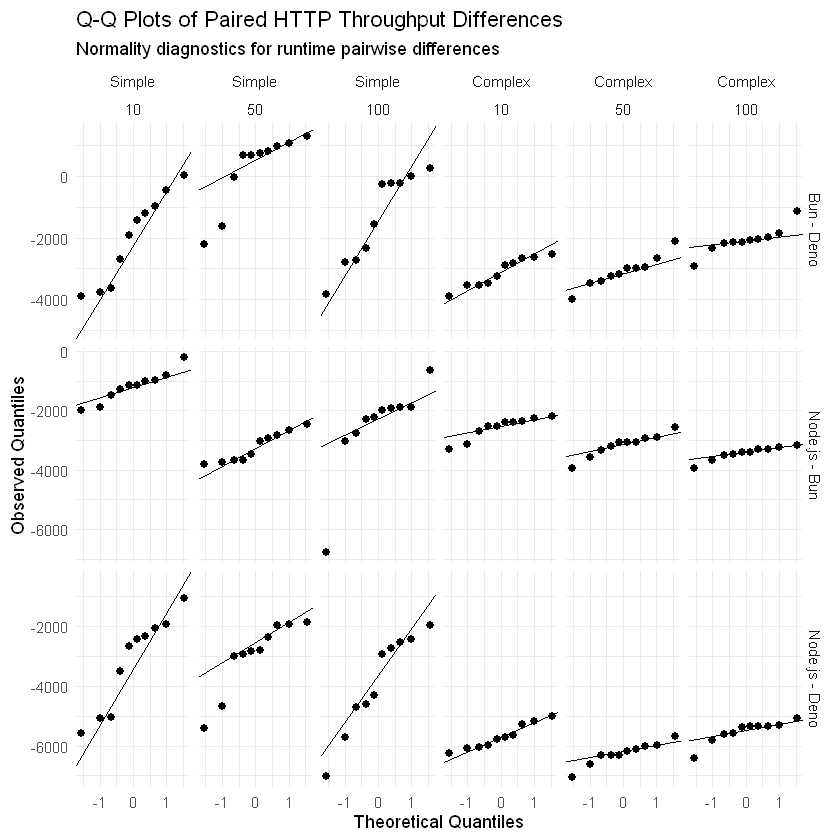

In [31]:
# Q-Q plot

http_throughput_qq <- ggplot(
  http_throughput_differences,
  aes(
    sample = difference
  )
) +
  stat_qq(
    size = 1.8
  ) +
  stat_qq_line() +
  facet_grid(
    comparison ~ workload + connections,
    scales = "free"
  ) +
  labs(
    title = "Q-Q Plots of Paired HTTP Throughput Differences",
    subtitle = "Normality diagnostics for runtime pairwise differences",
    x = "Theoretical Quantiles",
    y = "Observed Quantiles"
  ) +
  theme_minimal(
    base_size = 11
  )

http_throughput_qq

### HTTP Throughput Assumption Assessment

Normality of the paired runtime differences was assessed separately for each workload and connection condition using the Shapiro–Wilk test together with Q–Q plots.

The diagnostics indicated that the paired differences for **Simple/10**, **Complex/10**, and **Complex/50** were reasonably compatible with the normality assumption. These conditions will therefore be analysed using repeated-measures ANOVA.

In contrast, **Simple/50**, **Simple/100**, and **Complex/100** showed evidence of non-normality in at least one paired comparison, supported by visible departures in the corresponding Q–Q plots. These conditions will therefore be analysed using the non-parametric Friedman test.

No observations were removed on the basis of these diagnostics. Where unusual values were present, the analysis method was adapted rather than altering the validated benchmark data.

### Friedman Tests for HTTP Throughput

The paired-difference diagnostics indicated departures from normality for the Simple/50, Simple/100 and Complex/100 conditions. These conditions were therefore analysed using the Friedman test.

The Friedman test is a non-parametric repeated-measures test. It evaluates whether the three runtimes show systematically different performance ranks across the matched repetitions.

A statistically significant Friedman result indicates that at least one runtime differs from the others, but does not identify which runtime pairs are responsible for the difference. Where the omnibus test is significant, paired post-hoc comparisons will therefore be performed separately.

In [32]:
run_friedman <- function(data, workload_value, connections_value) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) == as.character(connections_value)
    )

  test <- friedman.test(
    requests_per_second ~ runtime | repetition,
    data = condition_data
  )

  n <- n_distinct(condition_data$repetition)
  k <- n_distinct(condition_data$runtime)

  tibble(
    workload = workload_value,
    connections = connections_value,

    chi_square = unname(
      test$statistic
    ),

    df = unname(
      test$parameter
    ),

    p_value = test$p.value,

    kendalls_w =
      unname(test$statistic) /
      (n * (k - 1))
  )
}


http_throughput_friedman <- bind_rows(

  run_friedman(
    http_final,
    "Simple",
    50
  ),

  run_friedman(
    http_final,
    "Simple",
    100
  ),

  run_friedman(
    http_final,
    "Complex",
    100
  )
)

http_throughput_friedman

workload,connections,chi_square,df,p_value,kendalls_w
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,50,15.8,2,3.707435e-04,0.79
Simple,100,18.2,2,1.116658e-04,0.91
Complex,100,20.0,2,4.539993e-05,1.00


#### Friedman Test Results

The Friedman tests identified statistically significant differences in HTTP throughput between Node.js, Bun and Deno for all three non-parametric conditions.

- **Simple/50:** χ²(2) = 15.80, p < .001, Kendall's W = .79.
- **Simple/100:** χ²(2) = 18.20, p < .001, Kendall's W = .91.
- **Complex/100:** χ²(2) = 20.00, p < .001, Kendall's W = 1.00.

The effect sizes indicate strong to extremely strong consistency in runtime rankings. The Complex/100 condition produced a Kendall's W of 1.00, indicating identical runtime ordering across all ten matched repetitions.

Because the omnibus tests were significant, paired post-hoc comparisons are required to determine which runtime pairs differ.

this test only tells us that at least one rntime is different from another 

### Repeated-Measures ANOVA for HTTP Throughput

The paired-difference diagnostics indicated that the Simple/10, Complex/10 and Complex/50 conditions were reasonably compatible with the normality assumption. These conditions were therefore analysed using one-way repeated-measures ANOVA.

The repeated-measures design accounts for the fact that Node.js, Bun and Deno were measured within the same repetition blocks.

Sphericity was assessed using Mauchly's test. Where the assumption was violated, the Greenhouse–Geisser correction was applied to the ANOVA result.

In [33]:
install.packages("rstatix")
library(rstatix)

Warning message:
"package 'rstatix' is in use and will not be installed"


In [34]:
run_rm_anova <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    ) |>
    mutate(
      repetition = factor(repetition)
    )

  result <- condition_data |>
    anova_test(
      dv = requests_per_second,
      wid = repetition,
      within = runtime,
      effect.size = "ges"
    )

  list(
    full_result = result,
    anova_table = get_anova_table(
      result,
      correction = "auto"
    )
  )
}

In [35]:
anova_simple_10 <- run_rm_anova(
  http_final,
  "Simple",
  10
)

anova_complex_10 <- run_rm_anova(
  http_final,
  "Complex",
  10
)

anova_complex_50 <- run_rm_anova(
  http_final,
  "Complex",
  50
)

In [36]:
anova_simple_10$anova_table

anova_complex_10$anova_table

anova_complex_50$anova_table

,Effect,DFn,DFd,F,p,p<.05,ges
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,runtime,1.17,10.55,32.742,0.000107,*,0.652


,Effect,DFn,DFd,F,p,p<.05,ges
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,runtime,2,18,912.128,8.12e-19,*,0.979


,Effect,DFn,DFd,F,p,p<.05,ges
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,runtime,2,18,1113.513,1.37e-19,*,0.985


In [37]:
anova_simple_10$full_result$`Mauchly's Test for Sphericity`

anova_complex_10$full_result$`Mauchly's Test for Sphericity`

anova_complex_50$full_result$`Mauchly's Test for Sphericity`

,Effect,W,p,p<.05
,<chr>,<dbl>,<dbl>,<chr>
1,runtime,0.295,0.008,*


,Effect,W,p,p<.05
,<chr>,<dbl>,<dbl>,<chr>
1,runtime,0.917,0.707,


,Effect,W,p,p<.05
,<chr>,<dbl>,<dbl>,<chr>
1,runtime,0.834,0.484,


#### Repeated-Measures ANOVA Results

Repeated-measures ANOVA identified statistically significant runtime effects for all three conditions analysed parametrically.

- **Simple/10:** F(1.17, 10.55) = 32.74, p < .001, generalized η² = .652. Mauchly's test indicated a violation of sphericity, W = .295, p = .008, so the Greenhouse–Geisser corrected result was used.
- **Complex/10:** F(2, 18) = 912.13, p < .001, generalized η² = .979. Mauchly's test did not indicate a violation of sphericity, W = .917, p = .707.
- **Complex/50:** F(2, 18) = 1113.51, p < .001, generalized η² = .985. Mauchly's test did not indicate a violation of sphericity, W = .834, p = .484.

The results indicate strong runtime effects on HTTP throughput across all three conditions. Because each omnibus ANOVA was statistically significant, paired post-hoc comparisons are required to determine which runtime pairs differ.

### Pairwise Post-Hoc Comparisons for HTTP Throughput

All six omnibus tests identified statistically significant runtime effects on HTTP throughput. Pairwise post-hoc comparisons were therefore performed to identify which runtime pairs differed.

For conditions analysed using repeated-measures ANOVA, paired t-tests were used. For conditions analysed using the Friedman test, paired Wilcoxon signed-rank tests were used.

The three runtime comparisons were:

- Node.js vs Bun;
- Node.js vs Deno; and
- Bun vs Deno.

Because multiple pairwise tests were performed within the HTTP throughput metric family, Holm's sequential correction was applied to the combined set of post-hoc p-values.

In [38]:
runtime_pairs <- list(
  c("Node.js", "Bun"),
  c("Node.js", "Deno"),
  c("Bun", "Deno")
)

In [39]:
run_paired_t_tests <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    )

  bind_rows(
    lapply(
      runtime_pairs,
      function(pair) {

        test_result <- stats::t.test(
          condition_data[[pair[1]]],
          condition_data[[pair[2]]],
          paired = TRUE
        )

        tibble(
          workload = workload_value,
          connections = connections_value,
          group1 = pair[1],
          group2 = pair[2],
          test_method = "Paired t-test",
          statistic = unname(test_result$statistic),
          df = unname(test_result$parameter),
          p_raw = test_result$p.value,
          mean_difference = mean(
            condition_data[[pair[1]]] -
              condition_data[[pair[2]]]
          )
        )
      }
    )
  )
}

In [40]:
run_paired_wilcoxon <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    )

  bind_rows(
    lapply(
      runtime_pairs,
      function(pair) {

        test_result <- stats::wilcox.test(
          condition_data[[pair[1]]],
          condition_data[[pair[2]]],
          paired = TRUE,
          exact = FALSE
        )

        tibble(
          workload = workload_value,
          connections = connections_value,
          group1 = pair[1],
          group2 = pair[2],
          test_method = "Wilcoxon signed-rank",
          statistic = unname(test_result$statistic),
          df = NA_real_,
          p_raw = test_result$p.value,
          mean_difference = mean(
            condition_data[[pair[1]]] -
              condition_data[[pair[2]]]
          )
        )
      }
    )
  )
}

In [41]:
posthoc_simple_10 <- run_paired_t_tests(
  http_throughput_wide,
  "Simple",
  10
)

posthoc_complex_10 <- run_paired_t_tests(
  http_throughput_wide,
  "Complex",
  10
)

posthoc_complex_50 <- run_paired_t_tests(
  http_throughput_wide,
  "Complex",
  50
)

In [42]:
posthoc_simple_10
posthoc_complex_10
posthoc_complex_50

workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,10,Node.js,Bun,Paired t-test,-7.268443,9,4.721728e-05,-1190.561
Simple,10,Node.js,Deno,Paired t-test,-6.481563,9,1.138687e-04,-3181.022
Simple,10,Bun,Deno,Paired t-test,-4.389161,9,1.747682e-03,-1990.461


workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Complex,10,Node.js,Bun,Paired t-test,-22.04992,9,3.833691e-09,-2578.761
Complex,10,Node.js,Deno,Paired t-test,-43.25139,9,9.426328e-12,-5700.595
Complex,10,Bun,Deno,Paired t-test,-20.78745,9,6.456991e-09,-3121.834


workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Complex,50,Node.js,Bun,Paired t-test,-26.59386,9,7.267243e-10,-3161.18
Complex,50,Node.js,Deno,Paired t-test,-53.12957,9,1.490007e-12,-6255.66
Complex,50,Bun,Deno,Paired t-test,-19.67989,9,1.046761e-08,-3094.48


In [43]:
posthoc_simple_50 <- run_paired_wilcoxon(
  http_throughput_wide,
  "Simple",
  50
)

posthoc_simple_100 <- run_paired_wilcoxon(
  http_throughput_wide,
  "Simple",
  100
)

posthoc_complex_100 <- run_paired_wilcoxon(
  http_throughput_wide,
  "Complex",
  100
)

posthoc_simple_50
posthoc_simple_100
posthoc_complex_100

workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,50,Node.js,Bun,Wilcoxon signed-rank,0,NA,0.005921537,-3231.156
Simple,50,Node.js,Deno,Wilcoxon signed-rank,0,NA,0.005921537,-2993.441
Simple,50,Bun,Deno,Wilcoxon signed-rank,35,NA,0.475532660,237.715


workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,100,Node.js,Bun,Wilcoxon signed-rank,0,NA,0.005921537,-2542.253
Simple,100,Node.js,Deno,Wilcoxon signed-rank,0,NA,0.005921537,-3909.959
Simple,100,Bun,Deno,Wilcoxon signed-rank,5,NA,0.024932456,-1367.706


workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Complex,100,Node.js,Bun,Wilcoxon signed-rank,0,NA,0.005921537,-3442.881
Complex,100,Node.js,Deno,Wilcoxon signed-rank,0,NA,0.005921537,-5523.902
Complex,100,Bun,Deno,Wilcoxon signed-rank,0,NA,0.005921537,-2081.021


In [44]:
http_throughput_posthoc <- bind_rows(
  posthoc_simple_10,
  posthoc_simple_50,
  posthoc_simple_100,
  posthoc_complex_10,
  posthoc_complex_50,
  posthoc_complex_100
)

In [45]:
http_throughput_posthoc <- http_throughput_posthoc |>
  mutate(
    p_holm = p.adjust(
      p_raw,
      method = "holm"
    ),
    significant = ifelse(
      p_holm < 0.05,
      "Yes",
      "No"
    )
  ) |>
  arrange(
    workload,
    connections,
    group1,
    group2
  )

http_throughput_posthoc

workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference,p_holm,significant
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Complex,10,Bun,Deno,Paired t-test,-20.787455,9,6.456991e-09,-3121.834,9.039788e-08,Yes
Complex,10,Node.js,Bun,Paired t-test,-22.049917,9,3.833691e-09,-2578.761,5.750537e-08,Yes
Complex,10,Node.js,Deno,Paired t-test,-43.251393,9,9.426328e-12,-5700.595,1.602476e-10,Yes
Complex,50,Bun,Deno,Paired t-test,-19.679886,9,1.046761e-08,-3094.480,1.360789e-07,Yes
Complex,50,Node.js,Bun,Paired t-test,-26.593862,9,7.267243e-10,-3161.180,1.162759e-08,Yes
Complex,50,Node.js,Deno,Paired t-test,-53.129571,9,1.490007e-12,-6255.660,2.682013e-11,Yes
Complex,100,Bun,Deno,Wilcoxon signed-rank,0.000000,NA,5.921537e-03,-2081.021,5.329383e-02,No
Complex,100,Node.js,Bun,Wilcoxon signed-rank,0.000000,NA,5.921537e-03,-3442.881,5.329383e-02,No
Complex,100,Node.js,Deno,Wilcoxon signed-rank,0.000000,NA,5.921537e-03,-5523.902,5.329383e-02,No


In [46]:
#  checking if the exac twilcoxon test is appropriate i.e. exact=FALSE 

wilcoxon_exact_check <- http_throughput_differences |>
  filter(
    (workload == "Simple" & connections %in% c(50, 100)) |
    (workload == "Complex" & connections == 100)
  ) |>
  group_by(
    workload,
    connections,
    comparison
  ) |>
  summarise(
    zero_differences = sum(difference == 0),
    duplicated_absolute_differences =
      sum(duplicated(abs(difference))),
    .groups = "drop"
  )

wilcoxon_exact_check

workload,connections,comparison,zero_differences,duplicated_absolute_differences
<fct>,<fct>,<chr>,<int>,<int>
Simple,50,Bun - Deno,0,0
Simple,50,Node.js - Bun,0,0
Simple,50,Node.js - Deno,0,0
Simple,100,Bun - Deno,0,0
Simple,100,Node.js - Bun,0,0
Simple,100,Node.js - Deno,0,0
Complex,100,Bun - Deno,0,0
Complex,100,Node.js - Bun,0,0
Complex,100,Node.js - Deno,0,0


In [47]:
# rewriting wilcoxon function 

run_paired_wilcoxon <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    )

  bind_rows(
    lapply(
      runtime_pairs,
      function(pair) {

        test_result <- stats::wilcox.test(
          condition_data[[pair[1]]],
          condition_data[[pair[2]]],
          paired = TRUE,
          exact = TRUE
        )

        tibble(
          workload = workload_value,
          connections = connections_value,
          group1 = pair[1],
          group2 = pair[2],
          test_method = "Wilcoxon signed-rank",
          statistic = unname(test_result$statistic),
          df = NA_real_,
          p_raw = test_result$p.value,
          mean_difference = mean(
            condition_data[[pair[1]]] -
            condition_data[[pair[2]]]
          )
        )
      }
    )
  )
}

In [48]:
posthoc_simple_50 <- run_paired_wilcoxon(
  http_throughput_wide, "Simple", 50
)

posthoc_simple_100 <- run_paired_wilcoxon(
  http_throughput_wide, "Simple", 100
)

posthoc_complex_100 <- run_paired_wilcoxon(
  http_throughput_wide, "Complex", 100
)

In [49]:
http_throughput_posthoc <- bind_rows(
  posthoc_simple_10,
  posthoc_simple_50,
  posthoc_simple_100,
  posthoc_complex_10,
  posthoc_complex_50,
  posthoc_complex_100
) |>
  mutate(
    p_holm = p.adjust(
      p_raw,
      method = "holm"
    ),
    significant = ifelse(
      p_holm < 0.05,
      "Yes",
      "No"
    )
  ) |>
  arrange(
    workload,
    connections,
    group1,
    group2
  )

http_throughput_posthoc

workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference,p_holm,significant
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Complex,10,Bun,Deno,Paired t-test,-20.787455,9,6.456991e-09,-3121.834,9.039788e-08,Yes
Complex,10,Node.js,Bun,Paired t-test,-22.049917,9,3.833691e-09,-2578.761,5.750537e-08,Yes
Complex,10,Node.js,Deno,Paired t-test,-43.251393,9,9.426328e-12,-5700.595,1.602476e-10,Yes
Complex,50,Bun,Deno,Paired t-test,-19.679886,9,1.046761e-08,-3094.480,1.360789e-07,Yes
Complex,50,Node.js,Bun,Paired t-test,-26.593862,9,7.267243e-10,-3161.180,1.162759e-08,Yes
Complex,50,Node.js,Deno,Paired t-test,-53.129571,9,1.490007e-12,-6255.660,2.682013e-11,Yes
Complex,100,Bun,Deno,Wilcoxon signed-rank,0.000000,NA,1.953125e-03,-2081.021,1.757812e-02,Yes
Complex,100,Node.js,Bun,Wilcoxon signed-rank,0.000000,NA,1.953125e-03,-3442.881,1.757812e-02,Yes
Complex,100,Node.js,Deno,Wilcoxon signed-rank,0.000000,NA,1.953125e-03,-5523.902,1.757812e-02,Yes


#### HTTP Throughput Post-Hoc Results

Pairwise post-hoc comparisons were conducted following the statistically significant omnibus tests. Paired t-tests were used for the conditions analysed using repeated-measures ANOVA, while exact paired Wilcoxon signed-rank tests were used for the non-parametric conditions. Exact Wilcoxon testing was appropriate because no zero paired differences or tied absolute differences were identified.

Holm's correction was applied across the 18 pairwise comparisons within the HTTP throughput metric family.

Seventeen of the eighteen pairwise comparisons remained statistically significant after adjustment. Node.js differed significantly from both Bun and Deno under every tested workload and connection condition. Bun and Deno also differed significantly in all conditions except the Simple workload at 50 concurrent connections (Holm-adjusted p = .492).

For Simple/50, Bun produced a slightly higher mean throughput than Deno (mean difference = 237.72 requests/s), but the paired comparison did not provide evidence of a statistically significant difference. For Simple/100, the Bun-Deno comparison remained significant after adjustment (Holm-adjusted p = .039), although this was the closest significant result to the .05 threshold.

| Condition     | Node.js vs Bun  | Node.js vs Deno | Bun vs Deno         |
| ------------- | --------------- | --------------- | ------------------- |
| Simple / 10   | **Significant** | **Significant** | **Significant**     |
| Simple / 50   | **Significant** | **Significant** | **Not significant** |
| Simple / 100  | **Significant** | **Significant** | **Significant**     |
| Complex / 10  | **Significant** | **Significant** | **Significant**     |
| Complex / 50  | **Significant** | **Significant** | **Significant**     |
| Complex / 100 | **Significant** | **Significant** | **Significant**     |


In [50]:
run_t_effects <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    )

  bind_rows(
    lapply(
      runtime_pairs,
      function(pair) {

        differences <-
          condition_data[[pair[1]]] -
          condition_data[[pair[2]]]

        test_result <- stats::t.test(
          differences,
          mu = 0,
          conf.level = 0.95
        )

        tibble(
          workload = workload_value,
          connections = connections_value,
          group1 = pair[1],
          group2 = pair[2],
          effect_type = "Cohen's dz",
          mean_difference = mean(differences),
          ci_lower = test_result$conf.int[1],
          ci_upper = test_result$conf.int[2],
          effect_size =
            mean(differences) /
            sd(differences)
        )
      }
    )
  )
}

In [51]:
run_wilcoxon_effects <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    )

  bind_rows(
    lapply(
      runtime_pairs,
      function(pair) {

        differences <-
          condition_data[[pair[1]]] -
          condition_data[[pair[2]]]

        ranks <- rank(
          abs(differences)
        )

        w_positive <- sum(
          ranks[differences > 0]
        )

        w_negative <- sum(
          ranks[differences < 0]
        )

        rank_biserial <-
          (w_positive - w_negative) /
          (w_positive + w_negative)

        test_result <- stats::wilcox.test(
          differences,
          mu = 0,
          exact = TRUE,
          conf.int = TRUE,
          conf.level = 0.95
        )

        tibble(
          workload = workload_value,
          connections = connections_value,
          group1 = pair[1],
          group2 = pair[2],
          effect_type =
            "Rank-biserial correlation",
          median_difference =
            median(differences),
          hodges_lehmann =
            unname(test_result$estimate),
          ci_lower =
            test_result$conf.int[1],
          ci_upper =
            test_result$conf.int[2],
          effect_size =
            rank_biserial
        )
      }
    )
  )
}

In [52]:
#download and load effectsize
install.packages("effectsize")
library(effectsize)

Warning message:
"package 'effectsize' is in use and will not be installed"


In [53]:
# effect size for paired t-test conditions

run_t_effects <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    )

  bind_rows(
    lapply(
      runtime_pairs,
      function(pair) {

        x <- condition_data[[pair[1]]]
        y <- condition_data[[pair[2]]]

        difference_test <- stats::t.test(
          x,
          y,
          paired = TRUE,
          conf.level = 0.95
        )

        effect_result <- effectsize::cohens_d(
          x,
          y,
          paired = TRUE,
          ci = 0.95
        )

        tibble(
          workload = workload_value,
          connections = connections_value,
          group1 = pair[1],
          group2 = pair[2],

          mean_difference = mean(x - y),

          difference_ci_lower =
            difference_test$conf.int[1],

          difference_ci_upper =
            difference_test$conf.int[2],

          effect_type = "Cohen's dz",

          effect_size =
            effect_result$Cohens_d,

          effect_ci_lower =
            effect_result$CI_low,

          effect_ci_upper =
            effect_result$CI_high
        )
      }
    )
  )
}

In [54]:
effects_simple_10 <- run_t_effects(
  http_throughput_wide,
  "Simple",
  10
)

effects_complex_10 <- run_t_effects(
  http_throughput_wide,
  "Complex",
  10
)

effects_complex_50 <- run_t_effects(
  http_throughput_wide,
  "Complex",
  50
)

For paired samples, 'repeated_measures_d()' provides more options.

For paired samples, 'repeated_measures_d()' provides more options.

For paired samples, 'repeated_measures_d()' provides more options.

For paired samples, 'repeated_measures_d()' provides more options.

For paired samples, 'repeated_measures_d()' provides more options.

For paired samples, 'repeated_measures_d()' provides more options.

For paired samples, 'repeated_measures_d()' provides more options.

For paired samples, 'repeated_measures_d()' provides more options.

For paired samples, 'repeated_measures_d()' provides more options.



In [55]:
#  effect size for wilcoxon conditions 

run_wilcoxon_effects <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    )

  bind_rows(
    lapply(
      runtime_pairs,
      function(pair) {

        x <- condition_data[[pair[1]]]
        y <- condition_data[[pair[2]]]

        wilcox_result <- stats::wilcox.test(
          x,
          y,
          paired = TRUE,
          exact = TRUE,
          conf.int = TRUE,
          conf.level = 0.95
        )

        effect_result <- effectsize::rank_biserial(
          x,
          y,
          paired = TRUE,
          ci = 0.95
        )

        tibble(
          workload = workload_value,
          connections = connections_value,
          group1 = pair[1],
          group2 = pair[2],

          median_difference =
            median(x - y),

          hodges_lehmann =
            unname(wilcox_result$estimate),

          difference_ci_lower =
            wilcox_result$conf.int[1],

          difference_ci_upper =
            wilcox_result$conf.int[2],

          effect_type =
            "Rank-biserial correlation",

          effect_size =
            effect_result$r_rank_biserial,

          effect_ci_lower =
            effect_result$CI_low,

          effect_ci_upper =
            effect_result$CI_high
        )
      }
    )
  )
}

In [56]:
effects_simple_50 <- run_wilcoxon_effects(
  http_throughput_wide,
  "Simple",
  50
)

effects_simple_100 <- run_wilcoxon_effects(
  http_throughput_wide,
  "Simple",
  100
)

effects_complex_100 <- run_wilcoxon_effects(
  http_throughput_wide,
  "Complex",
  100
)

In [57]:
# combined effect-size results
http_throughput_effects <- bind_rows(
  effects_simple_10,
  effects_simple_50,
  effects_simple_100,
  effects_complex_10,
  effects_complex_50,
  effects_complex_100
) |>
  arrange(
    workload,
    connections,
    group1,
    group2
  )

http_throughput_effects

workload,connections,group1,group2,mean_difference,difference_ci_lower,difference_ci_upper,effect_type,effect_size,effect_ci_lower,effect_ci_upper,median_difference,hodges_lehmann
<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Complex,10,Bun,Deno,-3121.834,-3461.562,-2782.1061,Cohen's dz,-6.5735703,-9.6141230,-3.5282262,NA,NA
Complex,10,Node.js,Bun,-2578.761,-2843.323,-2314.1993,Cohen's dz,-6.9727959,-10.1913010,-3.7509502,NA,NA
Complex,10,Node.js,Deno,-5700.595,-5998.751,-5402.4395,Cohen's dz,-13.6772912,-19.6461617,-7.4566526,NA,NA
Complex,50,Bun,Deno,-3094.480,-3450.183,-2738.7767,Cohen's dz,-6.2233265,-9.1080930,-3.3324206,NA,NA
Complex,50,Node.js,Bun,-3161.180,-3430.080,-2892.2801,Cohen's dz,-8.4097175,-12.1102629,-4.5495143,NA,NA
Complex,50,Node.js,Deno,-6255.660,-6522.014,-5989.3058,Cohen's dz,-16.8010454,-24.1206017,-9.1742476,NA,NA
Complex,100,Bun,Deno,NA,-2382.070,-1734.0650,Rank-biserial correlation,-1.0000000,-1.0000000,-1.0000000,-2118.935,-2094.935
Complex,100,Node.js,Bun,NA,-3620.805,-3290.9350,Rank-biserial correlation,-1.0000000,-1.0000000,-1.0000000,-3394.805,-3405.400
Complex,100,Node.js,Deno,NA,-5873.270,-5332.1350,Rank-biserial correlation,-1.0000000,-1.0000000,-1.0000000,-5366.035,-5465.635


#### HTTP Throughput Effect Sizes

Effect sizes and 95% confidence intervals were calculated for all pairwise runtime comparisons. Cohen's dz was used for comparisons conducted using paired t-tests, while matched-pairs rank-biserial correlation was used for comparisons conducted using Wilcoxon signed-rank tests.

The parametric comparisons showed large runtime effects, with all confidence intervals excluding zero. The direction of the effects consistently favoured Bun over Node.js and Deno over Node.js, while Deno also outperformed Bun in the Simple/10 and complex workload conditions.

For the non-parametric comparisons, several rank-biserial correlations reached -1.00, indicating that the second runtime in the comparison outperformed the first in every matched repetition. This occurred for Node.js versus Bun and Node.js versus Deno at Simple/50 and Simple/100, and for all three runtime comparisons at Complex/100.

The only comparison showing no statistically reliable difference was Bun versus Deno under the Simple workload at 50 concurrent connections. Its rank-biserial correlation was .273 with a 95% confidence interval spanning zero, consistent with the non-significant Holm-adjusted post-hoc result.

In [58]:
http_throughput_final_results <- http_throughput_posthoc |>
  left_join(
    http_throughput_effects |>
      select(
        workload,
        connections,
        group1,
        group2,
        effect_type,
        effect_size,
        effect_ci_lower,
        effect_ci_upper,
        difference_ci_lower,
        difference_ci_upper,
        hodges_lehmann
      ),
    by = c(
      "workload",
      "connections",
      "group1",
      "group2"
    )
  ) |>
  mutate(
    estimate = ifelse(
      test_method == "Wilcoxon signed-rank",
      hodges_lehmann,
      mean_difference
    )
  ) |>
  select(
    workload,
    connections,
    group1,
    group2,
    test_method,
    estimate,
    difference_ci_lower,
    difference_ci_upper,
    p_holm,
    significant,
    effect_type,
    effect_size,
    effect_ci_lower,
    effect_ci_upper
  )

http_throughput_final_results

workload,connections,group1,group2,test_method,estimate,difference_ci_lower,difference_ci_upper,p_holm,significant,effect_type,effect_size,effect_ci_lower,effect_ci_upper
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
Complex,10,Bun,Deno,Paired t-test,-3121.834,-3461.562,-2782.1061,9.039788e-08,Yes,Cohen's dz,-6.5735703,-9.6141230,-3.5282262
Complex,10,Node.js,Bun,Paired t-test,-2578.761,-2843.323,-2314.1993,5.750537e-08,Yes,Cohen's dz,-6.9727959,-10.1913010,-3.7509502
Complex,10,Node.js,Deno,Paired t-test,-5700.595,-5998.751,-5402.4395,1.602476e-10,Yes,Cohen's dz,-13.6772912,-19.6461617,-7.4566526
Complex,50,Bun,Deno,Paired t-test,-3094.480,-3450.183,-2738.7767,1.360789e-07,Yes,Cohen's dz,-6.2233265,-9.1080930,-3.3324206
Complex,50,Node.js,Bun,Paired t-test,-3161.180,-3430.080,-2892.2801,1.162759e-08,Yes,Cohen's dz,-8.4097175,-12.1102629,-4.5495143
Complex,50,Node.js,Deno,Paired t-test,-6255.660,-6522.014,-5989.3058,2.682013e-11,Yes,Cohen's dz,-16.8010454,-24.1206017,-9.1742476
Complex,100,Bun,Deno,Wilcoxon signed-rank,-2094.935,-2382.070,-1734.0650,1.757812e-02,Yes,Rank-biserial correlation,-1.0000000,-1.0000000,-1.0000000
Complex,100,Node.js,Bun,Wilcoxon signed-rank,-3405.400,-3620.805,-3290.9350,1.757812e-02,Yes,Rank-biserial correlation,-1.0000000,-1.0000000,-1.0000000
Complex,100,Node.js,Deno,Wilcoxon signed-rank,-5465.635,-5873.270,-5332.1350,1.757812e-02,Yes,Rank-biserial correlation,-1.0000000,-1.0000000,-1.0000000


## HTTP Latency Analysis

HTTP latency was evaluated using mean latency and 99th-percentile (p99) latency. Mean latency represents the average response time observed during each benchmark run, while p99 latency captures tail behaviour by representing the latency threshold below which 99% of requests completed.

Both metrics are expressed in milliseconds, and lower values indicate better performance.

The analysis follows the same repeated-measures structure used for HTTP throughput: descriptive statistics and visualisation are followed by assumption diagnostics, omnibus statistical tests, post-hoc comparisons where required, multiple-comparison correction, and effect-size estimation.

In [59]:
http_latency_long <- http_final |>
  select(
    workload,
    connections,
    repetition,
    runtime,
    mean_latency_ms,
    p99_latency_ms
  ) |>
  pivot_longer(
    cols = c(
      mean_latency_ms,
      p99_latency_ms
    ),
    names_to = "latency_metric",
    values_to = "latency_ms"
  ) |>
  mutate(
    latency_metric = factor(
      latency_metric,
      levels = c(
        "mean_latency_ms",
        "p99_latency_ms"
      ),
      labels = c(
        "Mean Latency",
        "P99 Latency"
      )
    )
  )

http_latency_long

workload,connections,repetition,runtime,latency_metric,latency_ms
<fct>,<fct>,<dbl>,<fct>,<fct>,<dbl>
Simple,10,1,Node.js,Mean Latency,0.05
Simple,10,1,Node.js,P99 Latency,1.00
Simple,10,2,Node.js,Mean Latency,0.06
Simple,10,2,Node.js,P99 Latency,1.00
Simple,10,3,Node.js,Mean Latency,0.05
Simple,10,3,Node.js,P99 Latency,1.00
Simple,10,4,Node.js,Mean Latency,0.05
Simple,10,4,Node.js,P99 Latency,1.00
Simple,10,5,Node.js,Mean Latency,0.04


In [60]:
dim(http_latency_long)
table(http_latency_long$latency_metric)

[1] 360   6


Mean Latency  P99 Latency 
         180          180 

In [61]:
http_latency_summary <- http_latency_long |>
  group_by(
    latency_metric,
    workload,
    connections,
    runtime
  ) |>
  summarise(
    n = n(),
    mean_ms = mean(latency_ms),
    median_ms = median(latency_ms),
    sd_ms = sd(latency_ms),
    se_ms = sd_ms / sqrt(n),

    ci_margin =
      qt(0.975, df = n - 1) * se_ms,

    ci_lower =
      mean_ms - ci_margin,

    ci_upper =
      mean_ms + ci_margin,

    iqr_ms = IQR(latency_ms),
    min_ms = min(latency_ms),
    max_ms = max(latency_ms),

    .groups = "drop"
  )

http_latency_summary

latency_metric,workload,connections,runtime,n,mean_ms,median_ms,sd_ms,se_ms,ci_margin,ci_lower,ci_upper,iqr_ms,min_ms,max_ms
<fct>,<fct>,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mean Latency,Simple,10,Node.js,10,0.049,0.050,0.005676462,0.001795055,0.004060696,0.04493930,0.05306070,0.0000,0.04,0.06
Mean Latency,Simple,10,Bun,10,0.119,0.120,0.011972190,0.003785939,0.008564389,0.11043561,0.12756439,0.0100,0.11,0.15
Mean Latency,Simple,10,Deno,10,0.035,0.030,0.007071068,0.002236068,0.005058337,0.02994166,0.04005834,0.0100,0.03,0.05
Mean Latency,Simple,50,Node.js,10,2.746,2.760,0.116351956,0.036793719,0.083233176,2.66276682,2.82923318,0.0650,2.53,2.95
Mean Latency,Simple,50,Bun,10,2.093,2.070,0.078888106,0.024946610,0.056433152,2.03656685,2.14943315,0.1150,1.99,2.23
Mean Latency,Simple,50,Deno,10,2.111,2.130,0.142318110,0.045004938,0.101808243,2.00919176,2.21280824,0.0650,1.83,2.32
Mean Latency,Simple,100,Node.js,10,6.122,5.930,0.718962215,0.227355815,0.514314586,5.60768541,6.63631459,0.2475,5.68,8.13
Mean Latency,Simple,100,Bun,10,5.192,5.140,0.261100236,0.082567144,0.186779857,5.00522014,5.37877986,0.0950,4.94,5.85
Mean Latency,Simple,100,Deno,10,4.850,4.985,0.341402337,0.107960898,0.244224519,4.60577548,5.09422452,0.6100,4.37,5.19


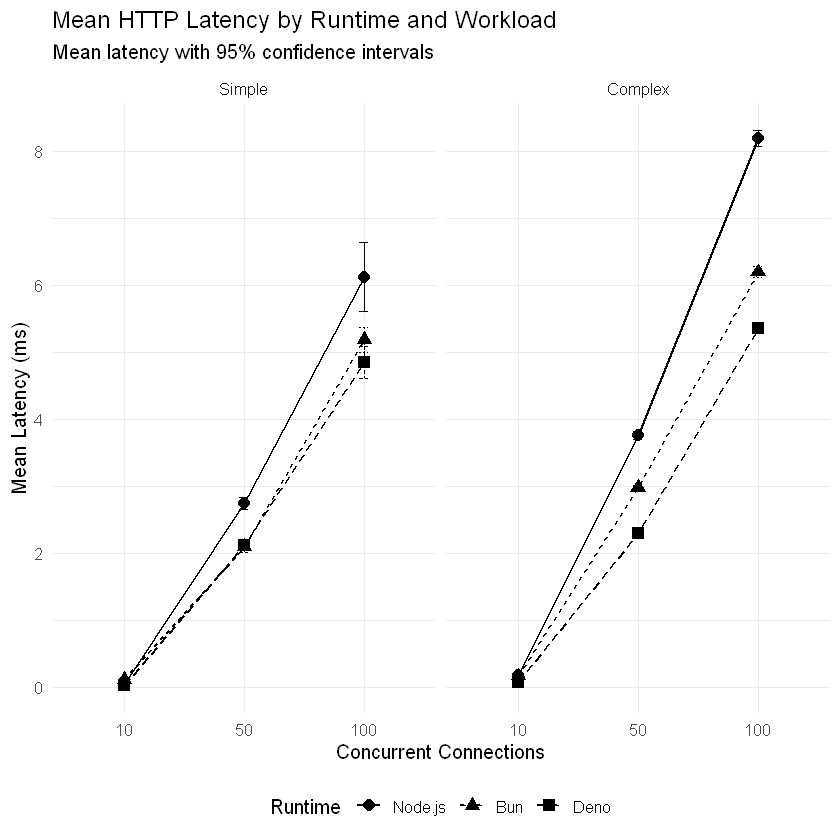

In [62]:
# mean latency figure

http_mean_latency_plot <- http_latency_summary |>
  filter(latency_metric == "Mean Latency") |>
  ggplot(
    aes(
      x = connections,
      y = mean_ms,
      group = runtime,
      shape = runtime,
      linetype = runtime
    )
  ) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 3) +
  geom_errorbar(
    aes(
      ymin = ci_lower,
      ymax = ci_upper
    ),
    width = 0.08
  ) +
  facet_wrap(~ workload) +
  labs(
    title = "Mean HTTP Latency by Runtime and Workload",
    subtitle = "Mean latency with 95% confidence intervals",
    x = "Concurrent Connections",
    y = "Mean Latency (ms)",
    shape = "Runtime",
    linetype = "Runtime"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "bottom"
  )

http_mean_latency_plot

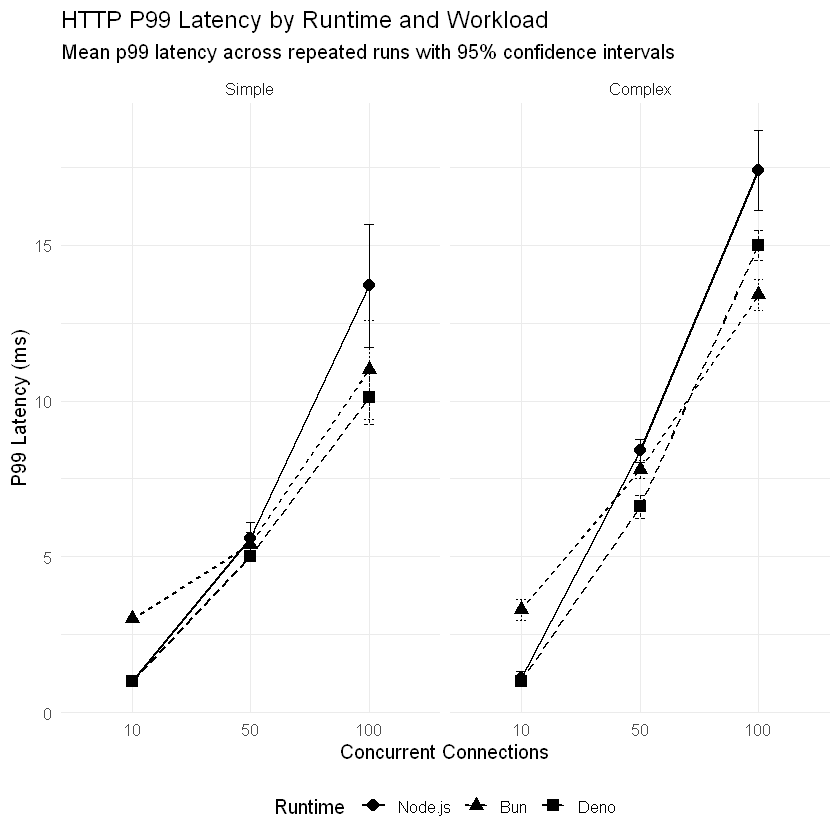

In [63]:
# p99 figure

http_p99_latency_plot <- http_latency_summary |>
  filter(latency_metric == "P99 Latency") |>
  ggplot(
    aes(
      x = connections,
      y = mean_ms,
      group = runtime,
      shape = runtime,
      linetype = runtime
    )
  ) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 3) +
  geom_errorbar(
    aes(
      ymin = ci_lower,
      ymax = ci_upper
    ),
    width = 0.08
  ) +
  facet_wrap(~ workload) +
  labs(
    title = "HTTP P99 Latency by Runtime and Workload",
    subtitle = "Mean p99 latency across repeated runs with 95% confidence intervals",
    x = "Concurrent Connections",
    y = "P99 Latency (ms)",
    shape = "Runtime",
    linetype = "Runtime"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "bottom"
  )

http_p99_latency_plot

In [64]:
http_mean_latency_wide <- http_final |>
  select(
    workload,
    connections,
    repetition,
    runtime,
    mean_latency_ms
  ) |>
  pivot_wider(
    names_from = runtime,
    values_from = mean_latency_ms
  )

http_mean_latency_wide

workload,connections,repetition,Node.js,Bun,Deno
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,10,1,0.05,0.12,0.04
Simple,10,2,0.06,0.15,0.04
Simple,10,3,0.05,0.12,0.04
Simple,10,4,0.05,0.12,0.03
Simple,10,5,0.04,0.12,0.03
Simple,10,6,0.05,0.11,0.03
Simple,10,7,0.05,0.11,0.03
Simple,10,8,0.05,0.11,0.03
Simple,10,9,0.04,0.11,0.03


In [65]:
dim(http_mean_latency_wide)
colSums(is.na(http_mean_latency_wide))

[1] 60  6

workload connections  repetition     Node.js         Bun        Deno 
          0           0           0           0           0           0

In [66]:
http_mean_latency_differences <- http_mean_latency_wide |>
  mutate(
    `Node.js - Bun` =
      `Node.js` - Bun,

    `Node.js - Deno` =
      `Node.js` - Deno,

    `Bun - Deno` =
      Bun - Deno
  ) |>
  select(
    workload,
    connections,
    repetition,
    `Node.js - Bun`,
    `Node.js - Deno`,
    `Bun - Deno`
  ) |>
  pivot_longer(
    cols = c(
      `Node.js - Bun`,
      `Node.js - Deno`,
      `Bun - Deno`
    ),
    names_to = "comparison",
    values_to = "difference"
  )

http_mean_latency_differences

workload,connections,repetition,comparison,difference
<fct>,<fct>,<dbl>,<chr>,<dbl>
Simple,10,1,Node.js - Bun,-0.07
Simple,10,1,Node.js - Deno,0.01
Simple,10,1,Bun - Deno,0.08
Simple,10,2,Node.js - Bun,-0.09
Simple,10,2,Node.js - Deno,0.02
Simple,10,2,Bun - Deno,0.11
Simple,10,3,Node.js - Bun,-0.07
Simple,10,3,Node.js - Deno,0.01
Simple,10,3,Bun - Deno,0.08


In [67]:
# shapiro wilks test

http_mean_latency_shapiro <- http_mean_latency_differences |>
  group_by(
    workload,
    connections,
    comparison
  ) |>
  summarise(
    W = unname(
      shapiro.test(difference)$statistic
    ),
    p_value =
      shapiro.test(difference)$p.value,
    .groups = "drop"
  )

http_mean_latency_shapiro

workload,connections,comparison,W,p_value
<fct>,<fct>,<chr>,<dbl>,<dbl>
Simple,10,Bun - Deno,0.7745436,7.103923e-03
Simple,10,Node.js - Bun,0.8407370,4.503041e-02
Simple,10,Node.js - Deno,0.7808946,8.488973e-03
Simple,50,Bun - Deno,0.8234700,2.791104e-02
Simple,50,Node.js - Bun,0.9499385,6.677725e-01
Simple,50,Node.js - Deno,0.9366495,5.163681e-01
Simple,100,Bun - Deno,0.8793453,1.282529e-01
Simple,100,Node.js - Bun,0.6207778,9.792462e-05
Simple,100,Node.js - Deno,0.7486631,3.437382e-03


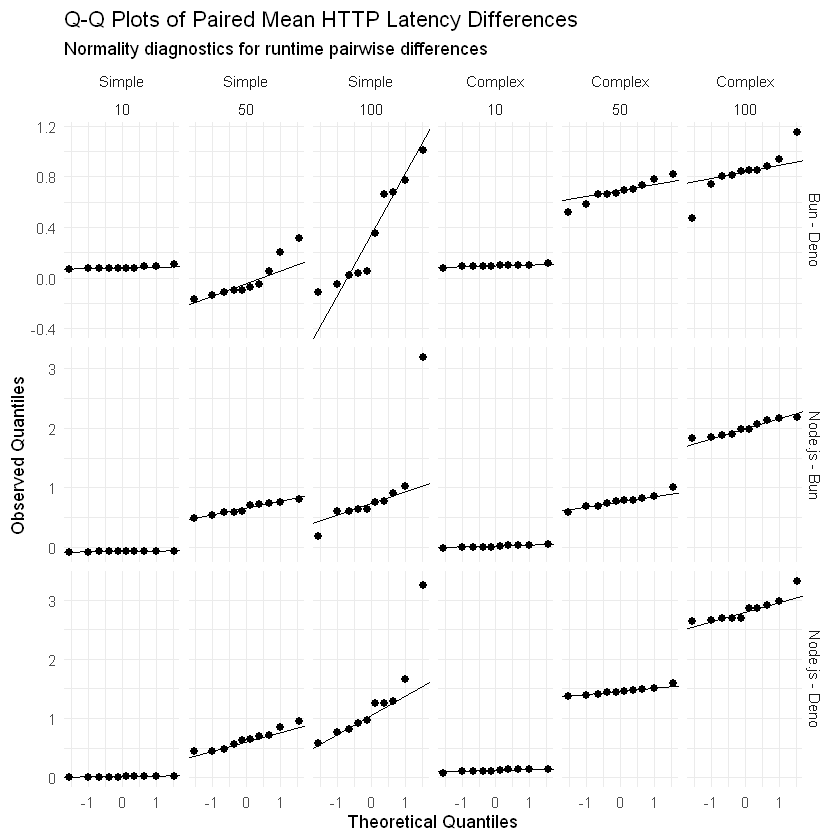

In [68]:
# Q-Q PLOT
http_mean_latency_qq <- ggplot(
  http_mean_latency_differences,
  aes(sample = difference)
) +
  stat_qq(size = 1.8) +
  stat_qq_line() +
  facet_grid(
    comparison ~ workload + connections,
    scales = "free"
  ) +
  labs(
    title = "Q-Q Plots of Paired Mean HTTP Latency Differences",
    subtitle = "Normality diagnostics for runtime pairwise differences",
    x = "Theoretical Quantiles",
    y = "Observed Quantiles"
  ) +
  theme_minimal(base_size = 11)

http_mean_latency_qq

### Mean HTTP Latency Assumption Assessment

Normality of the paired runtime differences was assessed using Shapiro–Wilk tests together with Q–Q plots.

The paired differences for **Complex/10** and **Complex/50** were reasonably compatible with the normality assumption and will therefore be analysed using repeated-measures ANOVA.

Evidence of non-normality was observed for **Simple/10**, **Simple/50**, **Simple/100**, and **Complex/100**. These conditions will therefore be analysed using the non-parametric Friedman test. The Simple/10 condition also contained highly discrete and tightly clustered latency differences, supporting the use of a rank-based method.

No observations were removed on the basis of these diagnostics.

In [69]:
# Friedman test for mean latency 

run_mean_latency_friedman <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    )

  test_result <- friedman.test(
    mean_latency_ms ~ runtime | repetition,
    data = condition_data
  )

  n <- n_distinct(condition_data$repetition)
  k <- n_distinct(condition_data$runtime)

  tibble(
    workload = workload_value,
    connections = connections_value,
    chi_square = unname(test_result$statistic),
    df = unname(test_result$parameter),
    p_value = test_result$p.value,
    kendalls_w =
      unname(test_result$statistic) /
      (n * (k - 1))
  )
}

In [70]:
http_mean_latency_friedman <- bind_rows(

  run_mean_latency_friedman(
    http_final,
    "Simple",
    10
  ),

  run_mean_latency_friedman(
    http_final,
    "Simple",
    50
  ),

  run_mean_latency_friedman(
    http_final,
    "Simple",
    100
  ),

  run_mean_latency_friedman(
    http_final,
    "Complex",
    100
  )
)

http_mean_latency_friedman

workload,connections,chi_square,df,p_value,kendalls_w
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,10,19.53846,2,5.718432e-05,0.9769231
Simple,50,15.80000,2,3.707435e-04,0.7900000
Simple,100,16.80000,2,2.248673e-04,0.8400000
Complex,100,20.00000,2,4.539993e-05,1.0000000


#### Friedman Test Results for Mean HTTP Latency

The Friedman tests identified statistically significant runtime effects on mean HTTP latency for all four non-parametric conditions.

- **Simple/10:** χ²(2) = 19.54, p < .001, Kendall's W = .977.
- **Simple/50:** χ²(2) = 15.80, p < .001, Kendall's W = .790.
- **Simple/100:** χ²(2) = 16.80, p < .001, Kendall's W = .840.
- **Complex/100:** χ²(2) = 20.00, p < .001, Kendall's W = 1.000.

The effect sizes indicate strong consistency in runtime rankings across repeated measurements. Because all four omnibus tests were statistically significant, pairwise post-hoc comparisons are required.

In [71]:
# ANOVA for mean latency

run_mean_latency_anova <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    ) |>
    mutate(
      repetition = factor(repetition)
    )

  result <- condition_data |>
    anova_test(
      dv = mean_latency_ms,
      wid = repetition,
      within = runtime,
      effect.size = "ges"
    )

  list(
    full_result = result,
    anova_table = get_anova_table(
      result,
      correction = "auto"
    )
  )
}

In [72]:
anova_mean_complex_10 <- run_mean_latency_anova(
  http_final,
  "Complex",
  10
)

anova_mean_complex_50 <- run_mean_latency_anova(
  http_final,
  "Complex",
  50
)

In [73]:
anova_mean_complex_10$anova_table

anova_mean_complex_50$anova_table

,Effect,DFn,DFd,F,p,p<.05,ges
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,runtime,2,18,285.819,2.3e-14,*,0.92


,Effect,DFn,DFd,F,p,p<.05,ges
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,runtime,2,18,1272.711,4.15e-20,*,0.987


In [74]:
anova_mean_complex_10$full_result$`Mauchly's Test for Sphericity`

anova_mean_complex_50$full_result$`Mauchly's Test for Sphericity`

,Effect,W,p,p<.05
,<chr>,<dbl>,<dbl>,<chr>
1,runtime,0.602,0.131,


,Effect,W,p,p<.05
,<chr>,<dbl>,<dbl>,<chr>
1,runtime,0.622,0.15,


#### Repeated-Measures ANOVA Results for Mean HTTP Latency

Repeated-measures ANOVA identified statistically significant runtime effects on mean HTTP latency for both parametrically analysed conditions.

- **Complex/10:** F(2, 18) = 285.82, p < .001, generalized η² = .920. Mauchly's test did not indicate a violation of sphericity, W = .602, p = .131.
- **Complex/50:** F(2, 18) = 1272.71, p < .001, generalized η² = .987. Mauchly's test did not indicate a violation of sphericity, W = .622, p = .150.

The results indicate very strong runtime effects on mean HTTP latency. Because both omnibus tests were significant, paired post-hoc comparisons are required.

In [75]:
mean_posthoc_simple_10 <- run_paired_wilcoxon(
  http_mean_latency_wide,
  "Simple",
  10
)

mean_posthoc_simple_50 <- run_paired_wilcoxon(
  http_mean_latency_wide,
  "Simple",
  50
)

mean_posthoc_simple_100 <- run_paired_wilcoxon(
  http_mean_latency_wide,
  "Simple",
  100
)

mean_posthoc_complex_100 <- run_paired_wilcoxon(
  http_mean_latency_wide,
  "Complex",
  100
)

In [76]:
mean_posthoc_complex_10 <- run_paired_t_tests(
  http_mean_latency_wide,
  "Complex",
  10
)

mean_posthoc_complex_50 <- run_paired_t_tests(
  http_mean_latency_wide,
  "Complex",
  50
)

In [77]:
http_mean_latency_posthoc <- bind_rows(
  mean_posthoc_simple_10,
  mean_posthoc_simple_50,
  mean_posthoc_simple_100,
  mean_posthoc_complex_10,
  mean_posthoc_complex_50,
  mean_posthoc_complex_100
) |>
  mutate(
    p_holm = p.adjust(
      p_raw,
      method = "holm"
    ),
    significant = ifelse(
      p_holm < 0.05,
      "Yes",
      "No"
    )
  ) |>
  arrange(
    workload,
    connections,
    group1,
    group2
  )

http_mean_latency_posthoc

workload,connections,group1,group2,test_method,statistic,df,p_raw,mean_difference,p_holm,significant
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Complex,10,Bun,Deno,Paired t-test,28.240723,9,4.256475e-10,0.096,7.236007e-09,Yes
Complex,10,Node.js,Bun,Paired t-test,3.612228,9,5.639676e-03,0.019,2.539062e-02,Yes
Complex,10,Node.js,Deno,Paired t-test,18.058125,9,2.230682e-08,0.115,3.122955e-07,Yes
Complex,50,Bun,Deno,Paired t-test,24.578805,9,1.464024e-09,0.681,2.342438e-08,Yes
Complex,50,Node.js,Bun,Paired t-test,21.435173,9,4.923326e-09,0.775,7.384989e-08,Yes
Complex,50,Node.js,Deno,Paired t-test,70.451613,9,1.182044e-13,1.456,2.127679e-12,Yes
Complex,100,Bun,Deno,Wilcoxon signed-rank,55.000000,NA,1.953125e-03,0.833,2.539062e-02,Yes
Complex,100,Node.js,Bun,Wilcoxon signed-rank,55.000000,NA,1.953125e-03,1.992,2.539062e-02,Yes
Complex,100,Node.js,Deno,Wilcoxon signed-rank,55.000000,NA,1.953125e-03,2.825,2.539062e-02,Yes


#### Mean HTTP Latency Post-Hoc Results

Pairwise post-hoc comparisons were performed following the significant omnibus tests. Paired t-tests were used for the parametrically analysed conditions and paired Wilcoxon signed-rank tests for the non-parametric conditions. Holm's correction was applied across the 18 comparisons within the mean HTTP latency metric family.

Sixteen of the eighteen pairwise comparisons remained statistically significant after adjustment. Node.js differed significantly from both Bun and Deno under every workload and connection condition.

The two non-significant comparisons were both between Bun and Deno under the Simple workload: Simple/50 (Holm-adjusted p = .539) and Simple/100 (Holm-adjusted p = .098). Although the unadjusted Bun-Deno comparison at Simple/100 was below .05, it did not remain significant after correction for multiple comparisons.

Under the Complex workload, all pairwise runtime comparisons remained statistically significant after Holm adjustment.

In [78]:
# mean latency effect size

mean_effects_simple_10 <- run_wilcoxon_effects(
  http_mean_latency_wide,
  "Simple",
  10
)

mean_effects_simple_50 <- run_wilcoxon_effects(
  http_mean_latency_wide,
  "Simple",
  50
)

mean_effects_simple_100 <- run_wilcoxon_effects(
  http_mean_latency_wide,
  "Simple",
  100
)

mean_effects_complex_100 <- run_wilcoxon_effects(
  http_mean_latency_wide,
  "Complex",
  100
)

In [79]:
mean_effects_complex_10 <- run_t_effects(
  http_mean_latency_wide,
  "Complex",
  10
)

mean_effects_complex_50 <- run_t_effects(
  http_mean_latency_wide,
  "Complex",
  50
)

For paired samples, 'repeated_measures_d()' provides more options.

For paired samples, 'repeated_measures_d()' provides more options.

For paired samples, 'repeated_measures_d()' provides more options.

For paired samples, 'repeated_measures_d()' provides more options.

For paired samples, 'repeated_measures_d()' provides more options.

For paired samples, 'repeated_measures_d()' provides more options.



In [80]:
http_mean_latency_effects <- bind_rows(
  mean_effects_simple_10,
  mean_effects_simple_50,
  mean_effects_simple_100,
  mean_effects_complex_10,
  mean_effects_complex_50,
  mean_effects_complex_100
) |>
  arrange(
    workload,
    connections,
    group1,
    group2
  )

http_mean_latency_effects

workload,connections,group1,group2,median_difference,hodges_lehmann,difference_ci_lower,difference_ci_upper,effect_type,effect_size,effect_ci_lower,effect_ci_upper,mean_difference
<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Complex,10,Bun,Deno,NA,NA,8.831014e-02,0.10368986,Cohen's dz,8.9305009,4.8380503,12.8543332,0.096
Complex,10,Node.js,Bun,NA,NA,7.101254e-03,0.03089875,Cohen's dz,1.1422869,0.3154422,1.9329862,0.019
Complex,10,Node.js,Deno,NA,NA,1.005938e-01,0.12940615,Cohen's dz,5.7104806,3.0448823,8.3678178,0.115
Complex,50,Bun,Deno,NA,NA,6.183229e-01,0.74367713,Cohen's dz,7.7725007,4.1958903,11.3484503,0.681
Complex,50,Node.js,Bun,NA,NA,6.932105e-01,0.85678949,Cohen's dz,6.7783968,3.6425539,9.9102033,0.775
Complex,50,Node.js,Deno,NA,NA,1.409249e+00,1.50275125,Cohen's dz,22.2787562,11.8970856,31.9706185,1.456
Complex,100,Bun,Deno,0.845,0.840,7.050000e-01,0.94500000,Rank-biserial correlation,1.0000000,1.0000000,1.0000000,NA
Complex,100,Node.js,Bun,1.975,1.995,1.885000e+00,2.09000000,Rank-biserial correlation,1.0000000,1.0000000,1.0000000,NA
Complex,100,Node.js,Deno,2.775,2.795,2.670000e+00,2.98000000,Rank-biserial correlation,1.0000000,1.0000000,1.0000000,NA


#### Mean HTTP Latency Effect Sizes

Effect sizes and 95% confidence intervals were calculated for all pairwise mean-latency comparisons. Cohen's dz was used following paired t-tests, while matched-pairs rank-biserial correlation was used following Wilcoxon signed-rank tests.

Most comparisons showed large and highly consistent runtime effects. Several non-parametric comparisons produced rank-biserial correlations of ±1.00, indicating that one runtime had lower latency than the other in every matched repetition.

The Bun-Deno comparison at Simple/50 showed a small rank-biserial effect with a confidence interval spanning zero, consistent with its non-significant Holm-adjusted result. At Simple/100, the Bun-Deno effect was comparatively large, but the pairwise difference did not remain statistically significant after Holm correction; therefore, no statistically reliable difference is claimed for that condition.

In [81]:
http_mean_latency_final_results <- http_mean_latency_posthoc |>
  left_join(
    http_mean_latency_effects |>
      select(
        workload,
        connections,
        group1,
        group2,
        effect_type,
        effect_size,
        effect_ci_lower,
        effect_ci_upper,
        difference_ci_lower,
        difference_ci_upper,
        hodges_lehmann
      ),
    by = c(
      "workload",
      "connections",
      "group1",
      "group2"
    )
  ) |>
  mutate(
    estimate = ifelse(
      test_method == "Wilcoxon signed-rank",
      hodges_lehmann,
      mean_difference
    )
  ) |>
  select(
    workload,
    connections,
    group1,
    group2,
    test_method,
    estimate,
    difference_ci_lower,
    difference_ci_upper,
    p_holm,
    significant,
    effect_type,
    effect_size,
    effect_ci_lower,
    effect_ci_upper
  )

http_mean_latency_final_results

workload,connections,group1,group2,test_method,estimate,difference_ci_lower,difference_ci_upper,p_holm,significant,effect_type,effect_size,effect_ci_lower,effect_ci_upper
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
Complex,10,Bun,Deno,Paired t-test,0.096,8.831014e-02,0.10368986,7.236007e-09,Yes,Cohen's dz,8.9305009,4.8380503,12.8543332
Complex,10,Node.js,Bun,Paired t-test,0.019,7.101254e-03,0.03089875,2.539062e-02,Yes,Cohen's dz,1.1422869,0.3154422,1.9329862
Complex,10,Node.js,Deno,Paired t-test,0.115,1.005938e-01,0.12940615,3.122955e-07,Yes,Cohen's dz,5.7104806,3.0448823,8.3678178
Complex,50,Bun,Deno,Paired t-test,0.681,6.183229e-01,0.74367713,2.342438e-08,Yes,Cohen's dz,7.7725007,4.1958903,11.3484503
Complex,50,Node.js,Bun,Paired t-test,0.775,6.932105e-01,0.85678949,7.384989e-08,Yes,Cohen's dz,6.7783968,3.6425539,9.9102033
Complex,50,Node.js,Deno,Paired t-test,1.456,1.409249e+00,1.50275125,2.127679e-12,Yes,Cohen's dz,22.2787562,11.8970856,31.9706185
Complex,100,Bun,Deno,Wilcoxon signed-rank,0.840,7.050000e-01,0.94500000,2.539062e-02,Yes,Rank-biserial correlation,1.0000000,1.0000000,1.0000000
Complex,100,Node.js,Bun,Wilcoxon signed-rank,1.995,1.885000e+00,2.09000000,2.539062e-02,Yes,Rank-biserial correlation,1.0000000,1.0000000,1.0000000
Complex,100,Node.js,Deno,Wilcoxon signed-rank,2.795,2.670000e+00,2.98000000,2.539062e-02,Yes,Rank-biserial correlation,1.0000000,1.0000000,1.0000000


## p99 Latency

In [82]:
http_p99_latency_wide <- http_final |>
  select(
    workload,
    connections,
    repetition,
    runtime,
    p99_latency_ms
  ) |>
  pivot_wider(
    names_from = runtime,
    values_from = p99_latency_ms
  )

dim(http_p99_latency_wide)
colSums(is.na(http_p99_latency_wide))

[1] 60  6

workload connections  repetition     Node.js         Bun        Deno 
          0           0           0           0           0           0

In [83]:
http_p99_latency_differences <- http_p99_latency_wide |>
  mutate(
    `Node.js - Bun` =
      `Node.js` - Bun,

    `Node.js - Deno` =
      `Node.js` - Deno,

    `Bun - Deno` =
      Bun - Deno
  ) |>
  select(
    workload,
    connections,
    repetition,
    `Node.js - Bun`,
    `Node.js - Deno`,
    `Bun - Deno`
  ) |>
  pivot_longer(
    cols = c(
      `Node.js - Bun`,
      `Node.js - Deno`,
      `Bun - Deno`
    ),
    names_to = "comparison",
    values_to = "difference"
  )

In [84]:
safe_shapiro_w <- function(x) {

  if (length(unique(x)) == 1) {
    return(NA_real_)
  }

  unname(
    stats::shapiro.test(x)$statistic
  )
}


safe_shapiro_p <- function(x) {

  if (length(unique(x)) == 1) {
    return(NA_real_)
  }

  stats::shapiro.test(x)$p.value
}

In [85]:
http_p99_latency_shapiro <- http_p99_latency_differences |>
  group_by(
    workload,
    connections,
    comparison
  ) |>
  summarise(
    unique_values =
      n_distinct(difference),

    W =
      safe_shapiro_w(difference),

    p_value =
      safe_shapiro_p(difference),

    diagnostic = ifelse(
      unique_values == 1,
      "Constant differences",
      "Shapiro-Wilk available"
    ),

    .groups = "drop"
  )

http_p99_latency_shapiro

workload,connections,comparison,unique_values,W,p_value,diagnostic
<fct>,<fct>,<chr>,<int>,<dbl>,<dbl>,<chr>
Simple,10,Bun - Deno,1,NA,NA,Constant differences
Simple,10,Node.js - Bun,1,NA,NA,Constant differences
Simple,10,Node.js - Deno,1,NA,NA,Constant differences
Simple,50,Bun - Deno,2,0.6404852,1.686791e-04,Shapiro-Wilk available
Simple,50,Node.js - Bun,3,0.7940640,1.227871e-02,Shapiro-Wilk available
Simple,50,Node.js - Deno,3,0.7808946,8.488973e-03,Shapiro-Wilk available
Simple,100,Bun - Deno,7,0.8910426,1.742183e-01,Shapiro-Wilk available
Simple,100,Node.js - Bun,6,0.8085957,1.843740e-02,Shapiro-Wilk available
Simple,100,Node.js - Deno,7,0.8744328,1.125559e-01,Shapiro-Wilk available


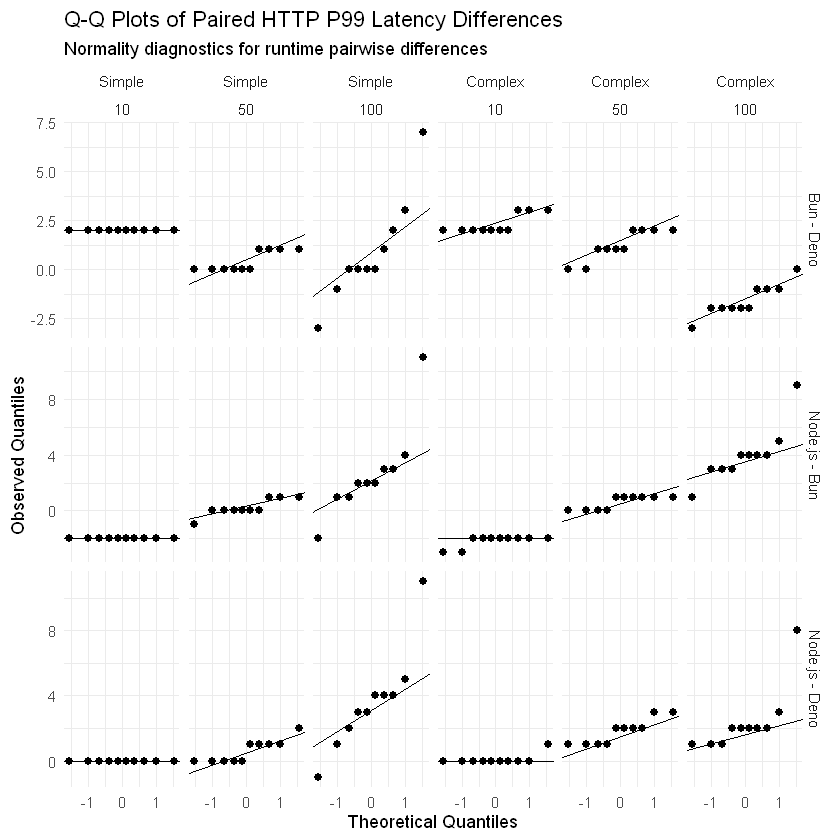

In [86]:
# p99 latency Q-Q plot

http_p99_latency_qq <- ggplot(
  http_p99_latency_differences,
  aes(sample = difference)
) +
  stat_qq(size = 1.8) +
  stat_qq_line() +
  facet_grid(
    comparison ~ workload + connections,
    scales = "free"
  ) +
  labs(
    title = "Q-Q Plots of Paired HTTP P99 Latency Differences",
    subtitle = "Normality diagnostics for runtime pairwise differences",
    x = "Theoretical Quantiles",
    y = "Observed Quantiles"
  ) +
  theme_minimal(base_size = 11)

http_p99_latency_qq

### P99 HTTP Latency Assumption Assessment

P99 latency exhibited strongly discrete behaviour across the repeated benchmark runs. Several paired runtime differences contained only a small number of unique values, and the Simple/10 condition contained constant paired differences for all three runtime comparisons, preventing application of the Shapiro–Wilk test.

For the remaining conditions, multiple Shapiro–Wilk tests indicated significant departures from normality, while the Q–Q plots showed substantial clustering and step-like patterns consistent with the discrete nature of the P99 measurements.

Consequently, all six workload and connection conditions were analysed using the non-parametric Friedman test. No observations were removed on the basis of these diagnostics.

In [87]:
# running friedman for all six conditions
run_p99_friedman <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    )

  test_result <- stats::friedman.test(
    p99_latency_ms ~ runtime | repetition,
    data = condition_data
  )

  n <- n_distinct(
    condition_data$repetition
  )

  k <- n_distinct(
    condition_data$runtime
  )

  tibble(
    workload = workload_value,
    connections = connections_value,
    chi_square =
      unname(test_result$statistic),
    df =
      unname(test_result$parameter),
    p_value =
      test_result$p.value,
    kendalls_w =
      unname(test_result$statistic) /
      (n * (k - 1))
  )
}

In [88]:
http_p99_latency_friedman <- bind_rows(

  run_p99_friedman(
    http_final,
    "Simple",
    10
  ),

  run_p99_friedman(
    http_final,
    "Simple",
    50
  ),

  run_p99_friedman(
    http_final,
    "Simple",
    100
  ),

  run_p99_friedman(
    http_final,
    "Complex",
    10
  ),

  run_p99_friedman(
    http_final,
    "Complex",
    50
  ),

  run_p99_friedman(
    http_final,
    "Complex",
    100
  )
)

http_p99_latency_friedman

workload,connections,chi_square,df,p_value,kendalls_w
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Simple,10,20.000000,2,4.539993e-05,1.0000000
Simple,50,7.052632,2,2.941308e-02,0.3526316
Simple,100,10.888889,2,4.320239e-03,0.5444444
Complex,10,19.419355,2,6.069329e-05,0.9709677
Complex,50,17.176471,2,1.862845e-04,0.8588235
Complex,100,19.538462,2,5.718432e-05,0.9769231


#### Friedman Test Results for P99 HTTP Latency

Friedman tests identified statistically significant runtime effects on P99 HTTP latency for all six workload and connection conditions.

- **Simple/10:** χ²(2) = 20.00, p < .001, Kendall's W = 1.000.
- **Simple/50:** χ²(2) = 7.05, p = .029, Kendall's W = .353.
- **Simple/100:** χ²(2) = 10.89, p = .004, Kendall's W = .544.
- **Complex/10:** χ²(2) = 19.42, p < .001, Kendall's W = .971.
- **Complex/50:** χ²(2) = 17.18, p < .001, Kendall's W = .859.
- **Complex/100:** χ²(2) = 19.54, p < .001, Kendall's W = .977.

The strength of the runtime ranking effect varied across conditions. Simple/50 showed the weakest consistency, whereas the remaining conditions generally showed strong to near-perfect consistency. At Simple/10, the perfect Kendall's W reflected a repeated ranking pattern in which Node.js and Deno were tied while Bun consistently exhibited higher P99 latency.

Because all omnibus tests were statistically significant, pairwise post-hoc comparisons were conducted.

In [89]:
exact_signed_rank_test <- function(differences) {

  # Remove zero differences, as in the standard
  # Wilcoxon signed-rank procedure
  nonzero <- differences[differences != 0]

  # If every paired difference is zero
  if (length(nonzero) == 0) {

    return(
      list(
        statistic = 0,
        p_value = 1,
        n_nonzero = 0
      )
    )
  }

  # Average ranks automatically handle tied
  # absolute differences
  ranks <- rank(
    abs(nonzero),
    ties.method = "average"
  )

  observed_w <- sum(
    ranks[nonzero > 0]
  )

  n <- length(nonzero)

  # Enumerate every possible +/- sign allocation
  sign_matrix <- expand.grid(
    rep(
      list(c(-1, 1)),
      n
    )
  )

  possible_w <- apply(
    sign_matrix,
    1,
    function(signs) {
      sum(
        ranks[signs > 0]
      )
    }
  )

  lower_tail <- mean(
    possible_w <= observed_w
  )

  upper_tail <- mean(
    possible_w >= observed_w
  )

  p_two_sided <- min(
    1,
    2 * min(
      lower_tail,
      upper_tail
    )
  )

  list(
    statistic = observed_w,
    p_value = p_two_sided,
    n_nonzero = n
  )
}

In [90]:
# pairwaise wrapper

run_p99_posthoc <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    )

  bind_rows(
    lapply(
      runtime_pairs,
      function(pair) {

        differences <-
          condition_data[[pair[1]]] -
          condition_data[[pair[2]]]

        result <-
          exact_signed_rank_test(
            differences
          )

        tibble(
          workload = workload_value,
          connections = connections_value,
          group1 = pair[1],
          group2 = pair[2],
          test_method =
            "Exact paired signed-rank",
          statistic =
            result$statistic,
          nonzero_pairs =
            result$n_nonzero,
          p_raw =
            result$p_value,
          median_difference =
            median(differences)
        )
      }
    )
  )
}

In [91]:
p99_posthoc_simple_10 <- run_p99_posthoc(
  http_p99_latency_wide,
  "Simple",
  10
)

p99_posthoc_simple_50 <- run_p99_posthoc(
  http_p99_latency_wide,
  "Simple",
  50
)

p99_posthoc_simple_100 <- run_p99_posthoc(
  http_p99_latency_wide,
  "Simple",
  100
)

p99_posthoc_complex_10 <- run_p99_posthoc(
  http_p99_latency_wide,
  "Complex",
  10
)

p99_posthoc_complex_50 <- run_p99_posthoc(
  http_p99_latency_wide,
  "Complex",
  50
)

p99_posthoc_complex_100 <- run_p99_posthoc(
  http_p99_latency_wide,
  "Complex",
  100
)

In [92]:
http_p99_latency_posthoc <- bind_rows(
  p99_posthoc_simple_10,
  p99_posthoc_simple_50,
  p99_posthoc_simple_100,
  p99_posthoc_complex_10,
  p99_posthoc_complex_50,
  p99_posthoc_complex_100
) |>
  mutate(
    p_holm = p.adjust(
      p_raw,
      method = "holm"
    ),
    significant = ifelse(
      p_holm < 0.05,
      "Yes",
      "No"
    )
  ) |>
  arrange(
    workload,
    connections,
    group1,
    group2
  )

http_p99_latency_posthoc

workload,connections,group1,group2,test_method,statistic,nonzero_pairs,p_raw,median_difference,p_holm,significant
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Complex,10,Bun,Deno,Exact paired signed-rank,55.0,10,0.001953125,2.0,0.03515625,Yes
Complex,10,Node.js,Bun,Exact paired signed-rank,0.0,10,0.001953125,-2.0,0.03515625,Yes
Complex,10,Node.js,Deno,Exact paired signed-rank,1.0,1,1.000000000,0.0,1.00000000,No
Complex,50,Bun,Deno,Exact paired signed-rank,36.0,8,0.007812500,1.0,0.07031250,No
Complex,50,Node.js,Bun,Exact paired signed-rank,21.0,6,0.031250000,1.0,0.21875000,No
Complex,50,Node.js,Deno,Exact paired signed-rank,55.0,10,0.001953125,2.0,0.03515625,Yes
Complex,100,Bun,Deno,Exact paired signed-rank,0.0,9,0.003906250,-2.0,0.04296875,Yes
Complex,100,Node.js,Bun,Exact paired signed-rank,55.0,10,0.001953125,4.0,0.03515625,Yes
Complex,100,Node.js,Deno,Exact paired signed-rank,55.0,10,0.001953125,2.0,0.03515625,Yes


#### P99 HTTP Latency Post-Hoc Results

Pairwise signed-rank comparisons were performed following the significant Friedman tests. Because P99 latency contained numerous tied and zero paired differences, exact sign-permutation probabilities were calculated while retaining average ranks for tied absolute differences. Holm's correction was applied across the 18 P99 pairwise comparisons.

Eight of the eighteen pairwise comparisons remained statistically significant after adjustment.

At **Simple/10**, Node.js and Deno had identical P99 latency across all ten repetitions, while both differed significantly from Bun. No pairwise comparison remained significant at Simple/50 or Simple/100 after Holm correction, despite significant omnibus Friedman tests.

At **Complex/10**, Bun differed significantly from both Node.js and Deno, while Node.js and Deno did not differ significantly. At **Complex/50**, only the Node.js-Deno comparison remained significant after adjustment.

At **Complex/100**, all three runtime pairs differed significantly. Bun had the lowest P99 latency, followed by Deno and then Node.js. This contrasts with mean latency, for which Deno produced the lowest value in this condition, demonstrating that average and tail-latency performance were not identical.

In [93]:
# p99 effect size

paired_rank_biserial <- function(differences) {

  nonzero <- differences[differences != 0]

  # If every pair is tied, the signed-rank
  # effect size is not estimable.
  if (length(nonzero) == 0) {
    return(NA_real_)
  }

  ranks <- rank(
    abs(nonzero),
    ties.method = "average"
  )

  w_positive <- sum(
    ranks[nonzero > 0]
  )

  w_negative <- sum(
    ranks[nonzero < 0]
  )

  (w_positive - w_negative) /
    (w_positive + w_negative)
}

In [94]:
bootstrap_p99_effect <- function(
  differences,
  B = 5000
) {

  if (all(differences == 0)) {

    return(
      tibble(
        effect_size = NA_real_,
        effect_ci_lower = NA_real_,
        effect_ci_upper = NA_real_,
        median_ci_lower = 0,
        median_ci_upper = 0
      )
    )
  }

  effect_boot <- replicate(
    B,
    {
      sampled <- sample(
        differences,
        size = length(differences),
        replace = TRUE
      )

      paired_rank_biserial(sampled)
    }
  )

  effect_boot <-
    effect_boot[
      is.finite(effect_boot)
    ]

  median_boot <- replicate(
    B,
    median(
      sample(
        differences,
        size = length(differences),
        replace = TRUE
      )
    )
  )

  tibble(
    effect_size =
      paired_rank_biserial(differences),

    effect_ci_lower =
      unname(
        quantile(
          effect_boot,
          0.025,
          na.rm = TRUE
        )
      ),

    effect_ci_upper =
      unname(
        quantile(
          effect_boot,
          0.975,
          na.rm = TRUE
        )
      ),

    median_ci_lower =
      unname(
        quantile(
          median_boot,
          0.025
        )
      ),

    median_ci_upper =
      unname(
        quantile(
          median_boot,
          0.975
        )
      )
  )
}

In [95]:
# condition function
run_p99_effects <- function(
  data,
  workload_value,
  connections_value
) {

  condition_data <- data |>
    filter(
      workload == workload_value,
      as.character(connections) ==
        as.character(connections_value)
    )

  bind_rows(
    lapply(
      runtime_pairs,
      function(pair) {

        differences <-
          condition_data[[pair[1]]] -
          condition_data[[pair[2]]]

        boot_result <-
          bootstrap_p99_effect(
            differences
          )

        tibble(
          workload = workload_value,
          connections = connections_value,
          group1 = pair[1],
          group2 = pair[2],
          median_difference =
            median(differences),
          nonzero_pairs =
            sum(differences != 0),
          effect_type =
            "Rank-biserial correlation"
        ) |>
          bind_cols(
            boot_result
          )
      }
    )
  )
}

In [96]:
set.seed(7303)

In [97]:
http_p99_latency_effects <- bind_rows(

  run_p99_effects(
    http_p99_latency_wide,
    "Simple",
    10
  ),

  run_p99_effects(
    http_p99_latency_wide,
    "Simple",
    50
  ),

  run_p99_effects(
    http_p99_latency_wide,
    "Simple",
    100
  ),

  run_p99_effects(
    http_p99_latency_wide,
    "Complex",
    10
  ),

  run_p99_effects(
    http_p99_latency_wide,
    "Complex",
    50
  ),

  run_p99_effects(
    http_p99_latency_wide,
    "Complex",
    100
  )
) |>
  arrange(
    workload,
    connections,
    group1,
    group2
  )

http_p99_latency_effects

workload,connections,group1,group2,median_difference,nonzero_pairs,effect_type,effect_size,effect_ci_lower,effect_ci_upper,median_ci_lower,median_ci_upper
<chr>,<dbl>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Complex,10,Bun,Deno,2.0,10,Rank-biserial correlation,1.0000000,1.0000000,1,2.0,3.0
Complex,10,Node.js,Bun,-2.0,10,Rank-biserial correlation,-1.0000000,-1.0000000,-1,-2.5,-2.0
Complex,10,Node.js,Deno,0.0,1,Rank-biserial correlation,1.0000000,1.0000000,1,0.0,0.0
Complex,50,Bun,Deno,1.0,8,Rank-biserial correlation,1.0000000,1.0000000,1,0.5,2.0
Complex,50,Node.js,Bun,1.0,6,Rank-biserial correlation,1.0000000,1.0000000,1,0.0,1.0
Complex,50,Node.js,Deno,2.0,10,Rank-biserial correlation,1.0000000,1.0000000,1,1.0,2.5
Complex,100,Bun,Deno,-2.0,9,Rank-biserial correlation,-1.0000000,-1.0000000,-1,-2.0,-1.0
Complex,100,Node.js,Bun,4.0,10,Rank-biserial correlation,1.0000000,1.0000000,1,3.0,4.5
Complex,100,Node.js,Deno,2.0,10,Rank-biserial correlation,1.0000000,1.0000000,1,1.0,2.5


#### P99 HTTP Latency Effect Sizes

Matched-pairs rank-biserial correlations were calculated to describe the direction and consistency of the P99 latency differences. Because P99 contained numerous tied observations, the effect-size estimates were interpreted together with the number of non-zero paired differences and the Holm-adjusted hypothesis tests.

Several comparisons produced rank-biserial correlations of ±1.00, indicating complete directional agreement among the non-zero paired differences. However, such values were not interpreted in isolation when only a small number of pairs differed. For example, the Complex/10 Node.js-Deno comparison contained only one non-zero pair and was not statistically significant after adjustment.

At Complex/100, all ten repetitions provided informative differences for the Node.js-Bun and Node.js-Deno comparisons, supporting the strong and statistically significant separation observed in the post-hoc analysis.

Overall, P99 latency exhibited more ties and weaker pairwise separation than mean latency, particularly under the Simple workload.

In [98]:
http_p99_latency_final_results <- http_p99_latency_posthoc |>
  left_join(
    http_p99_latency_effects |>
      select(
        workload,
        connections,
        group1,
        group2,
        effect_size,
        effect_ci_lower,
        effect_ci_upper,
        median_ci_lower,
        median_ci_upper
      ),
    by = c(
      "workload",
      "connections",
      "group1",
      "group2"
    )
  ) |>
  select(
    workload,
    connections,
    group1,
    group2,
    test_method,
    nonzero_pairs,
    median_difference,
    median_ci_lower,
    median_ci_upper,
    p_holm,
    significant,
    effect_size,
    effect_ci_lower,
    effect_ci_upper
  )

http_p99_latency_final_results

workload,connections,group1,group2,test_method,nonzero_pairs,median_difference,median_ci_lower,median_ci_upper,p_holm,significant,effect_size,effect_ci_lower,effect_ci_upper
<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
Complex,10,Bun,Deno,Exact paired signed-rank,10,2.0,2.0,3.0,0.03515625,Yes,1.0000000,1.0000000,1
Complex,10,Node.js,Bun,Exact paired signed-rank,10,-2.0,-2.5,-2.0,0.03515625,Yes,-1.0000000,-1.0000000,-1
Complex,10,Node.js,Deno,Exact paired signed-rank,1,0.0,0.0,0.0,1.00000000,No,1.0000000,1.0000000,1
Complex,50,Bun,Deno,Exact paired signed-rank,8,1.0,0.5,2.0,0.07031250,No,1.0000000,1.0000000,1
Complex,50,Node.js,Bun,Exact paired signed-rank,6,1.0,0.0,1.0,0.21875000,No,1.0000000,1.0000000,1
Complex,50,Node.js,Deno,Exact paired signed-rank,10,2.0,1.0,2.5,0.03515625,Yes,1.0000000,1.0000000,1
Complex,100,Bun,Deno,Exact paired signed-rank,9,-2.0,-2.0,-1.0,0.04296875,Yes,-1.0000000,-1.0000000,-1
Complex,100,Node.js,Bun,Exact paired signed-rank,10,4.0,3.0,4.5,0.03515625,Yes,1.0000000,1.0000000,1
Complex,100,Node.js,Deno,Exact paired signed-rank,10,2.0,1.0,2.5,0.03515625,Yes,1.0000000,1.0000000,1


## Save Final HTTP Analysis Outputs

The final descriptive and inferential outputs for HTTP throughput, mean latency and P99 latency are saved for later reporting and overall runtime ranking.

In [99]:
library(tidyverse)
library(rstatix)
library(effectsize)

current_dir <- normalizePath(
  getwd(),
  winslash = "/"
)

project_root <- if (
  basename(current_dir) == "notebooks"
) {
  dirname(current_dir)
} else {
  current_dir
}

project_root

[1] "D:/FOLO_PROJECTS/MASTERS/javascript-runtime-performance-study"

In [100]:
file.exists(
  file.path(
    project_root,
    "data",
    "processed",
    "http",
    "http_final_combined.csv"
  )
)

[1] TRUE

In [101]:
http_results_directory <- file.path(
  project_root,
  "results",
  "tables",
  "http"
)

dir.create(
  http_results_directory,
  recursive = TRUE,
  showWarnings = FALSE
)

In [102]:
write_csv(
  http_throughput_summary,
  file.path(
    http_results_directory,
    "http_throughput_descriptive_summary.csv"
  )
)

write_csv(
  http_latency_summary,
  file.path(
    http_results_directory,
    "http_latency_descriptive_summary.csv"
  )
)

In [103]:
write_csv(
  http_throughput_final_results,
  file.path(
    http_results_directory,
    "http_throughput_inferential_results.csv"
  )
)

write_csv(
  http_mean_latency_final_results,
  file.path(
    http_results_directory,
    "http_mean_latency_inferential_results.csv"
  )
)

write_csv(
  http_p99_latency_final_results,
  file.path(
    http_results_directory,
    "http_p99_latency_inferential_results.csv"
  )
)

In [104]:
write_csv(
  http_throughput_friedman,
  file.path(
    http_results_directory,
    "http_throughput_friedman_results.csv"
  )
)

write_csv(
  http_mean_latency_friedman,
  file.path(
    http_results_directory,
    "http_mean_latency_friedman_results.csv"
  )
)

write_csv(
  http_p99_latency_friedman,
  file.path(
    http_results_directory,
    "http_p99_latency_friedman_results.csv"
  )
)

In [105]:
http_throughput_anova_results <- bind_rows(
  anova_simple_10$anova_table |>
    mutate(
      workload = "Simple",
      connections = 10
    ),

  anova_complex_10$anova_table |>
    mutate(
      workload = "Complex",
      connections = 10
    ),

  anova_complex_50$anova_table |>
    mutate(
      workload = "Complex",
      connections = 50
    )
)

write_csv(
  http_throughput_anova_results,
  file.path(
    http_results_directory,
    "http_throughput_anova_results.csv"
  )
)

In [106]:
http_mean_latency_anova_results <- bind_rows(
  anova_mean_complex_10$anova_table |>
    mutate(
      workload = "Complex",
      connections = 10
    ),

  anova_mean_complex_50$anova_table |>
    mutate(
      workload = "Complex",
      connections = 50
    )
)

write_csv(
  http_mean_latency_anova_results,
  file.path(
    http_results_directory,
    "http_mean_latency_anova_results.csv"
  )
)